In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


from flame_net.lib_uti import count_learnable_params
from flame_net.libSiva import CSolverSiva
#from flame_net.uti_plot import *
import os

from flame_net.libSiva import libSiva
from flame_net.libData import libData


%matplotlib inline
import pickle

#np.random.seed(seed=1653)
from fractions import Fraction

In [2]:
#  Train/Validiation
# [1d-MS, 40] , [1d-MS, 10 ],  [1d-KS, 40] ,   [1d-KS, 10 ], [1d-KDV], [2d-kdv]
# str_title = [r"1d-MS($\beta=40$)", r"1d-MS($\beta=10$)",r"1d-KS($\beta=40$)",r"1d-KS($\beta=10$)",      r"1d-KDV",             r"2d-MS",             r"2d-KS",             r"2d-KDV",]
# dd_RevtFNO_n = [ [2.78e-3, 0.00762], [1.88e-4, 0.000194], [2.48e-4, 0.000265], [ 2.48E-4, 2.64E-4]  , [0.00043 , 5.0e-4 ], [4.36e-4,0.000322] , [3.34e-4,0.000351], [7.4e-4, 7.84e-4]]
# dd_RevtFNO_e = [ [0.0058, 0.0137 ]   ,[8.38e-4, 0.000861], [1.9e-3, 0.0020 ], [ 9.22E-4, 9.91e-4]   , [8.68e-4 , 9.22e-4] ,  [0.00128,0.00104], [1.97e-3,0.00211],  [2.8e-3, 2.8e-3]]
# dd_RevtFNO   = [ [0.00257, 0.00463 ] ,[8.42e-4, 0.00088], [1.186e-3, 0.002 ], [ 0.00114, 0.00118]     , [6.97e-4 , 0.000703] , None , None, None]
# dd_kFNO_n   = [ [0.0037, 0.01 ] ,[4.84e-4, 5.22e-4], [4.03e-4, 0.000428 ],[0.000393,4.24e-4],[7.92e-4,0.000824 ], None,None,None ]
# dd_kFNO_e   = [ [0.0083, 0.018 ] ,[1.02e-3, 1.04e-3], [2.15e-3, 0.00225 ],[1.56e-3 ,1.62e-3],[1.14e-3,0.00126]  , None,None,None ]
# dd_kFNO  = [ [0.0045, 0.0063], [0.0010 ,0.0011], [0.00074, 0.00075], [0.00078, 0.00082], [9.97e-4, 0.00109]    , [0.0015,0.0021], [0.0025,0.0025] , [1.3e-3, 1.3e-3]]
# dd_FNO   = [ [0.028, 0.028], [0.0033 ,0.0034], [0.0024, 0.0025], [0.0022, 0.0023] , [1.34e-3, 0.00144]  ,  [0.0041, 0.0030], [0.0053,0.0053], [0.0061,0.0062]]  

dict_title = {'1dMS40':r"1d-MS($\beta=40$)", '1dMS25':r"1d-MS($\beta=25$)", '1dMS10':r"1d-MS($\beta=10$)",'1dKS40':r"1d-KS($\beta=40$)", '1dKS25':r"1d-KS($\beta=25$)", '1dKS10':r"1d-KS($\beta=10$)",'1dKDV':r"1d-KDV", '2dMS':r"2d-MS", '2dKS':r"2d-KS", '2dKDV':'2d-KDV'}

dict_err_RevtFNO_n= {'1dMS40':[2.78e-3, 0.00762],'1dMS25':[5.7e-4, 7.7e-4], '1dMS10':[1.88e-4,0.000194],'1dKS40':[2.48e-4, 0.000265],'1dKS25': [2.57e-4,2.68e-4 ], '1dKS10':[ 1.92E-4, 2.02E-4], '1dKDV':[5.85e-4,5.27e-4 ], '2dMS':[4.36e-4,0.000322] , '2dKS':[3.34e-4,0.000351],'2dKDV':[4.3e-4, 4.3e-4] }
dict_err_RevtFNO_e= {'1dMS40':[0.0058, 0.0137 ] ,'1dMS25':[1.6e-3, 2.1e-3],'1dMS10':[8.38e-4,0.000861], '1dKS40':[1.9e-3, 0.0020], '1dKS25': [9.4e-4, 9.9e-4  ], '1dKS10':[ 9.22E-4, 9.91e-4]  , '1dKDV':[8.68e-4,9.22e-4] ,'2dMS':None,   '2dKS':None, '2dKDV':None } # '2dMS':[0.00128,0.00104], '2dKS':[1.97e-3,0.00211], '2dKDV':[2.8e-3, 2.9e-3]
dict_err_RevtFNO  = {'1dMS40':[0.0058, 0.0079],'1dMS25':[1.2e-3, 1.8e-3],'1dMS10':[8.42e-4,0.00088], '1dKS40':[0.00186, 0.002 ],'1dKS25': [1.1e-3, 1.2e-3  ], '1dKS10':[ 0.00114, 0.00118], '1dKDV':[6.97e-4,0.000703] ,'2dMS': None , '2dKS':None, '2dKDV':None }
dict_err_kFNO_n   = {'1dMS40':[0.0037, 0.01 ] ,'1dMS25':[7.0e-4, 8.9e-4], '1dMS10':[4.12e-4,4.6e-4], '1dKS40':[4.03e-4, 0.000428 ],'1dKS25':[4.1e-4, 4.2e-4  ],'1dKS10':[0.000393,4.24e-4],'1dKDV':[7.26e-4,7.06e-4],'2dMS':None, '2dKS':None,'2dKDV':None  }
dict_err_kFNO_e   = {'1dMS40':[0.0083, 0.018] ,'1dMS25':[2.8e-3, 4.2e-3 ], '1dMS10':[1.02e-3,1.04e-3], '1dKS40':[2.15e-3, 0.00225 ],'1dKS25':[1.6e-3,1.7e-3   ],'1dKS10':[1.56e-3 ,1.62e-3],'1dKDV':[1.14e-3,0.00126]  ,'2dMS':None, '2dKS':None,'2dKDV':None  }
dict_err_kFNO     = {'1dMS40':[0.0045, 0.0063], '1dMS25':[3.2e-3,3.5e-3 ], '1dMS10':[0.0010,0.0011], '1dKS40':[0.00074, 0.00075],   '1dKS25':[2.0e-3,2.1e-3 ], '1dKS10':[0.00078, 0.00082], '1dKDV':[9.97e-4, 0.00109] , '2dMS':[0.0015,0.0021], '2dKS':[0.0025,0.0025] , '2dKDV':[5.0e-4, 5.0e-4]}
dict_err_FNO      = {'1dMS40':[0.028, 0.028], '1dMS25':[0.02, 0.02],      '1dMS10':[0.0033,0.0034], '1dKS40':[0.0024, 0.0025],     '1dKS25':[0.011,0.012], '1dKS10':[0.0022, 0.0023]     , '1dKDV':[1.34e-3, 0.00144]  , '2dMS':[0.0041, 0.0030], '2dKS':[0.0053,0.0053], '2dKDV':[3.07e-3, 3.07e-3] }

dict_err_RevtFNO_e_kappa  = {'1dMS40':None,'1dMS25':None,'1dMS10':None, '1dKS40':None,'1dKS25':None, '1dKS10':None, '1dKDV':[1.17e-3,0.0012], '2dMS': None,  '2dKS':None, '2dKDV':None}
dict_err_RevtFNO_e_kappa3 = {'1dMS40':None,'1dMS25':None,'1dMS10':None, '1dKS40':None, '1dKS25':None, '1dKS10':None, '1dKDV':[1.34e-3,0.00160] ,'2dMS': None, '2dKS': None, '2dKDV':None}
#----------------------



#-------------------
# [1d-MS, 25] , [1d-MS, 10 ],  [1d-KS, 25] ,   [1d-KS, 10 ], [1d-KDV], [2d-kdv]
# str_title = [r"1d-MS($\beta=25$)", r"1d-MS($\beta=10$)",r"1d-KS($\beta=25$)",r"1d-KS($\beta=10$)",      r"1d-KDV",             r"2d-MS",             r"2d-KS",             r"2d-KDV",]
# dd_RevtFNO_n = [ '1dMS25':[5.7e-4, 7.7e-4] , [1.88e-4, 0.000194],'1dKS25': [2.57e-4,2.68e-4 ], [ 2.48E-4, 2.64E-4]  , [0.00043 , 5.0e-4 ], [4.36e-4,0.000322] , [3.34e-4,0.000351], [7.4e-4, 7.84e-4]]
# dd_RevtFNO_e = [ '1dMS25':[1.6e-3, 2.1e-3 ]  , [8.38e-4, 0.000861],'1dKS25': [9.4e-4, 9.9e-4  ], [ 9.22E-4, 9.91e-4]   , [8.68e-4 , 9.22e-4] ,  [0.00128,0.00104], [1.97e-3,0.00211],  [2.8e-3, 2.8e-3]]
# dd_RevtFNO   = [ '1dMS25':[1.2e-3, 1.8e-3 ]  , [8.42e-4, 0.00088],'1dKS25': [1.1e-3, 1.2e-3  ], [ 0.00114, 0.00118]     , [6.97e-4 , 0.000703] , None , None, None]

# dd_kFNO_n   = [ '1dMS25':[7.0e-4, 8.9e-4 ] ,[4.84e-4, 5.22e-4], '1dKS25':[4.1e-4, 4.2e-4  ],[0.000393,4.24e-4],[7.92e-4,0.000824 ], None,None,None ]
# dd_kFNO_e   = [ '1dMS25':[2.8e-3, 4.2e-3 ] ,[1.02e-3, 1.04e-3], '1dKS25':[1.6e-3,1.7e-3   ],[1.56e-3 ,1.62e-3],[1.14e-3,0.00126]  , None,None,None ]
# dd_kFNO  = [ '1dMS25':[3.2e-3,3.5e-3 ], [0.0010 ,0.0011],     '1dKS25':[2.0e-3,2.1e-3 ], [0.00078, 0.00082], [9.97e-4, 0.00109]    , [0.0015,0.0021], [0.0025,0.0025] , [1.3e-3, 1.3e-3] ]
# dd_FNO   = [ '1dMS25':[0.02, 0.02],      [0.0033 ,0.0034],     '1dKS25':[0.011,0.012], [0.0022, 0.0023] , [1.34e-3, 0.00144]  ,  [0.0041, 0.0030], [0.0053,0.0053], [0.0050,0.0051]]  
#------------------

list_key = ['1dKS10','1dKS40','1dMS10','1dMS40', '1dKDV','2dKS', '2dMS', '2dKDV']
#list_key = ['1dMS40','1dMS10','2dMS','1dKS40','1dKS10','2dKS','1dKDV','2dKDV']
#list_key = ['1dMS25','1dMS10','1dKS25','1dKS10','2dMS','2dKS','1dKDV','2dKDV']

err_RevtFNO_n = [ dict_err_RevtFNO_n[key] for key in list_key ]
err_RevtFNO_e = [ dict_err_RevtFNO_e[key] for key in list_key ]
err_RevtFNO   = [ dict_err_RevtFNO[key]   for key in list_key ]
err_kFNO_n = [ dict_err_kFNO_n[key] for key in list_key ]
err_kFNO_e = [ dict_err_kFNO_e[key] for key in list_key ]
err_kFNO = [ dict_err_kFNO[key] for key in list_key ]
err_FNO = [ dict_err_FNO[key] for key in list_key ]
err_RevtFNO_e_kappa  = [ dict_err_RevtFNO_e_kappa[key] for key in list_key ]
err_RevtFNO_e_kappa3 = [ dict_err_RevtFNO_e_kappa3[key] for key in list_key ]


          
NNN = len(list_key)

str_title =  [ dict_title[key] for key in list_key ]

#----------------
model_err_data = [ err_RevtFNO_n, err_RevtFNO, err_RevtFNO_e, err_RevtFNO_e_kappa, err_RevtFNO_e_kappa3,      err_kFNO_n, err_kFNO,  err_kFNO_e, err_FNO ]
model_label    = ["IS-FNO$^o$", "IS-FNO$^*$", "IS-FNO'", "IS-FNO'$_\kappa$", "IS-FNO'$_{\kappa3}$",    "kFNO$^o$", "kFNO$^*$", "kFNO'", "FNO" ]
model_color    = ['red'       , 'purple',    'yellow',   'orange',           'violet',                   'g',      'b',         'c',    'lightgrey']

# model_err_data = [ err_RevtFNO_n, err_RevtFNO, err_RevtFNO_e,  err_RevtFNO_e_kappa3,      err_kFNO_n, err_kFNO,  err_kFNO_e, err_FNO ]
# model_label    = ["IS-FNO$^n$", "IS-FNO$^*$", "IS-FNO'",      "IS-FNO'$_{\kappa3}$",    "kFNO$^n$", "kFNO$^*$", "kFNO'", "FNO" ]
# model_color    = ['red'       , 'purple',    'yellow',         'violet',                   'g',      'b',         'c',    'lightgrey']
#--------------

#list_cases = [ 7,7,7,7,9,4,4,4]

list_cases = [ 0 for key in list_key ] 
for i, key in enumerate(list_key) :
  for err_model_j in model_err_data: 
      if err_model_j[i] is not None:
            list_cases[i]  += 1



In [3]:
list_cases

[7, 7, 7, 7, 9, 3, 3, 3]

/local/tmp.5495154/ipykernel_1173070/323281694.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Train/Valid'], fontsize =13)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


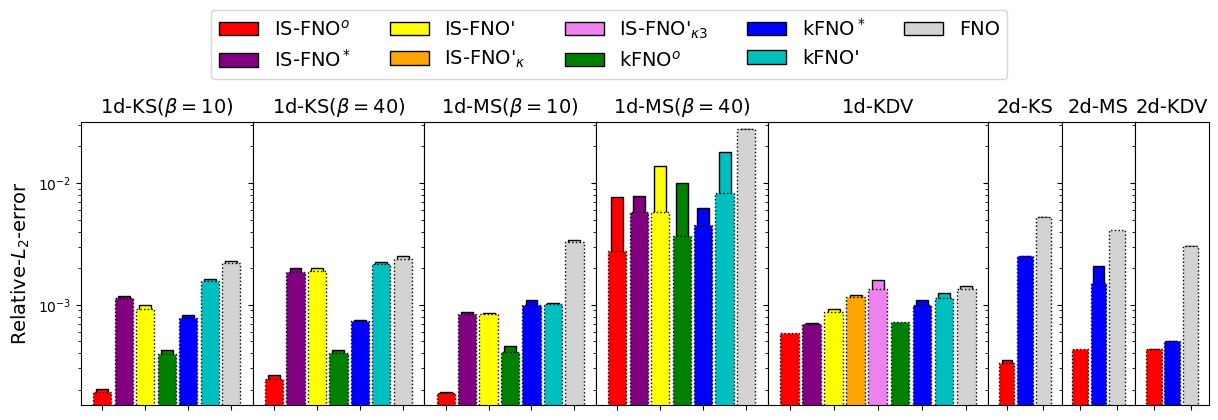

In [4]:


gs_kw = dict(width_ratios=list_cases )
fig,axs = plt.subplots(1,NNN, figsize=(12,4.5),sharey=True, gridspec_kw=gs_kw )

#br = np.arange(2)
#=================
for j in range(NNN):
    
    #r_j = 0.5 if j==0 else 1
    r_j = 1

    w = 1/(list_cases[j]+1)
    ww = w*0.85
    
    #j0 = 2*(j-1)
    j0=j
    ax = axs[j] 

    s = 0
    for k , (model_err, color, label) in enumerate(zip(model_err_data, model_color, model_label ) ):
      if  model_err[j] is not None:
          ax.bar( s*w, model_err[j][1]*r_j, color =color, width = ww*.65, edgecolor ='k', label = label) ; 
          ax.bar( s*w, model_err[j][0]*r_j, color =color, width = ww, edgecolor ='k', linestyle=':' ) ; # label = label
          s = s+1
    
    ax.set_ylim([1.5E-4, 3.2E-2])
    ax.set_xlim([-w, 1-w])    #ax.set_xticks(br+0.5-w)    #ax.set_xticks(br+0.5-w)
    ax.set_xticklabels(['Train/Valid'], fontsize =13)
#=================

lines, labels = axs[ np.argmax(list_cases)  ].get_legend_handles_labels()
fig.legend(lines, labels, ncol=5, fontsize=14,  loc = 'upper center' )


fig.tight_layout()
plt.subplots_adjust(left=0.06,bottom=0.1, right=1, top=.73, wspace=0.0) #left=0.08



#str_title = [r"DL, $\beta=40$",r"DL, $\beta=40$", r"DL, $\beta=10$",r"DT, $\beta=40$",r"DT, $\beta=10$"]

for j in range(NNN):
    ax = axs[j]
    ax.set_yscale("log") 
    ax.set_title(str_title[j], fontsize =14)
    #ax.set_ylim([1e-4,4e-2])

    if j==0:
        ax.set_ylabel(r"Relative-$L_2$-error",fontsize=14)

    
#if png_filename is not None:
png_filename = 'ErrorTable_siva_1d.eps' 
plt.savefig(png_filename, format='eps')


In [5]:
device = torch.device('cuda')
#bRNN=False
T_in=1
data_channel = 1 # model.data_channel

In [6]:
models=[
  {'alias':'tFNO250_k1'  ,'act_para':[25,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_0_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO250'     ,'act_para':[25,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_0_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
  {'alias':'tFNO250_n'   ,'act_para':[25,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_0_tAdvD1_exp_nonl_o20'       ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'tFNO250_e'   ,'act_para':[25,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_0_tAdvD1_exp_o20'           ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO250_n','act_para':[25,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho25_0_tAdvD1_exp_nonl_o20'   ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO250_e','act_para':[25,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho25_0_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO250'  ,'act_para':[25,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho25_0_o20'                   ,'nStep':1,'Tout':20,'proj_dir':'.'},

  {'alias':'tFNO251_k1'  ,'act_para':[25,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_1_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO251'     ,'act_para':[25,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_1_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
  {'alias':'tFNO251_n'   ,'act_para':[25,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_1_tAdvD1_exp_nonl_o20'       ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'tFNO251_e'   ,'act_para':[25,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho25_1_tAdvD1_exp_o20'           ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO251_n','act_para':[25,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run3_RevtFNO_m128w30Lpi_rho25_1_tAdvD1_exp_nonl_o20_ep900'   ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO251_e','act_para':[25,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho25_1_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO251'  ,'act_para':[25,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho25_1_o20'                   ,'nStep':1,'Tout':20,'proj_dir':'.'},

    
  {'alias':'tFNO400_k1','act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO400'   ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
  {'alias':'tFNO400_n' ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_tAdvD1_exp_nonl_o20'          ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'tFNO400_e' ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_tAdvD1_exp_o20'           ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO400_n' ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho40_0_tAdvD1_exp_nonl_o20'     ,'nStep':1,'Tout':20,'proj_dir':'.'},
 #{'alias':'RevtFNO400_e','act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128rm32w30Lpi_rho40_0_tAdvD1_exp_o20_best'     ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO400_e' ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_0_tAdvD1_exp_o20'     ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO400'   ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_0_o20'                ,'nStep':1,'Tout':20,'proj_dir':'.'},
   
  #---
  {'alias':'tFNO100_k1'  ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_0_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO100'     ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_0_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
  {'alias':'tFNO100_n'   ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_0_tAdvD1_exp_nonl_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'tFNO100_e'   ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_tFNO_m128w30Lpi_rho10_0_tAdvD1_exp_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO100_n','act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho10_0_tAdvD1_exp_nonl_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO100_e','act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128rm32w30Lpi_rho10_0_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO100'  ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho10_0_o20'     ,'nStep':1,'Tout':20,'proj_dir':'.'},
  # ---
  {'alias':'tFNO101_k1'  ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_1_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO101'     ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_1_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
    
  {'alias':'tFNO101_n'   ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run3_tFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonl_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'tFNO101_e'   ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_tFNO_m128w30Lpi_rho10_1_tAdvD1_exp_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO101_n','act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonl_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
  #{'alias':'RevtFNO101_n','act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonlraw_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO101_e','act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO101'  ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128rm32w30Lpi_rho10_1_o20'     ,'nStep':1,'Tout':20,'proj_dir':'.'},

  # ---
  {'alias':'tFNO401_k1'  ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_1_noskip_o20_k1'    ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO401'     ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_tFNO_m128w30Lpi_rho40_1_noskip_o20'   ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
  {'alias':'tFNO401_n'   ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'lr5e4_tFNO_m128w30Lpi_rho40_1_tAdvD1_exp_nonlraw_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'tFNO401_e'   ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_1_tAdvD1_exp_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
  #{'alias':'RevtFNO401_n','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho40_1_noskip_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
  #{'alias':'RevtFNO401_e','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_1_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},
  #{'alias':'RevtFNO401_n','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'lr1e3_RevtFNO_m128w30Lpi_rho40_1_tAdvD1_exp_nonlraw_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
  #{'alias':'RevtFNO401_n','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_1_tAdvD1_exp_nonl_noskip_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},

  {'alias':'RevtFNO401_n','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_1_tAdvD1_exp_nonlraw_o20','nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO401_e','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_1_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},
  {'alias':'RevtFNO401'  ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_1_o20'                   ,'nStep':1,'Tout':20,'proj_dir':'.'},
  #------------
   
]

In [7]:
#models[-1]=   {'alias':'RevtFNO401'  ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_1_o20'     ,'nStep':1,'Tout':20,'proj_dir':'.'}

def change_to_new_model(model_alias, new_model_name_detail=None, models=models):
    for k, model in enumerate(models):
        if model['alias'] == model_alias: 
            print('model_index=', k, ', to be changed model name is:' , model['model_name_detail'] )
            if new_model_name_detail is None: 
                return
            break
    model['model_name_detail']= new_model_name_detail
    print('change to ', new_model_name_detail)
    model['para_list'] = []

    key_pop_list = []    
    for j,  key in enumerate(model):
        if j >= 8:
            key_pop_list.append( key)

    for key in key_pop_list:
        print(key, ' deleted')
        model.pop(key, None)
                        
                
    return

In [8]:
#change_to_new_model('tFNO100_n','run2_tFNO_m128w30Lpi_rho10_0_tAdvD1_exp_nonl_o20')

In [9]:
def load_pkl( m ):
    str_filename = m['model_name_detail'] 
    if str_filename.find('_ep') >=0:         str_filename  = str_filename[ : str_filename.find('_ep') ]
    if str_filename.find('_best')>=0:        str_filename  = str_filename[ : str_filename.find('_best') ]
    open_file=open( m['proj_dir']+'/checkpoints/'+str_filename+ 'trainlog.pkl','rb')
    output_dict= pickle.load(open_file)
    open_file.close()
    train_residual = np.array ( [ os for os  in output_dict['list_output_info'] ] )
    return train_residual 
    
def plot_training_resid( m, list_iy=[2,3], ys='log',ix=0):
    train_residual = load_pkl( m)
    line_style = ['r-', 'g-.','b--','k.']
    for idx, y in enumerate(list_iy):
        plt.plot( train_residual[:,ix], train_residual[:,y], line_style[idx])
        #plt.plot( train_residual[:,ix], train_residual[:,y],'b-')
    plt.yscale(ys)
    
    return [ train_residual[:, y ][-1] for  y in list_iy ]

def print_train_info( list_iy=[2,3,1], models=models ):
    for idx, m in enumerate( models):
        train_residual = load_pkl( m)
        #----------------
        if 'ONet' in m['model_name_detail']:            method='ONet'
        elif  'Fourier' in m['model_name_detail']:      method='Fourier'
        elif  'Conv' in m['model_name_detail']:         method='Conv'
        #----------------
        print(idx, method, m['model_name_detail'], m['nStep'] ,m['Tout'],  [ train_residual[:, y ][-1] for  y in list_iy ] ) 

In [10]:
num_total_step=2000

In [11]:
list__init_str = 20*['rand_simple']
list__init_str_LongTerm= np.arange(20)
list_randseed = np.arange(20)+ 5457   # 136 # +236 # 457

siva = [  {'para_name':'Lpi_rho', 'para_list':[], 'SivaEq':CSolverSiva('MKS_RK4', [[10,0], [40,1]], method_default_siva_data_gen=4), 'N':256 ,'list_randseed':list_randseed  },]


siva_sys_name= MKS_RK4
N= 256 ,dt_Output= 0.15 ,self.list_para = [[10, 0], [40, 1]] ,

In [12]:
# list__init_str = ['rand_simple','rand_simple','rand_simple','rand_simple','rand_simple','rand_simple' ]
# list__init_str_LongTerm=[3]
# list_randseed = [33,1283,39,43,578,789]
# siva = [  {'para_name':'Lpi_rho', 'para_list':[], 'SivaEq':CSolverSiva('MKS_RK4', [[10,0], [40,1]], method_default_siva_data_gen=4), 'N':256 ,'list_randseed':list_randseed  },]


In [13]:
def get_para_key( para_name, each_para_value):  # note: 'each_para_value' is allowed to be a list of values
    if 'Lpi_rho'== para_name:   return 'Lpi{:d}rho{:g}_'.format(each_para_value[0],each_para_value[1])
    else:                       return '{}{:.3f}_'.format(para_name, each_para_value)
    

def get_sys(para_dict,siva=siva):
    for sys in siva:
        if para_dict['para_name'] == sys['para_name'] :    return sys
    raise ValueError('did not find sys')

def get_d0(i_which,sys,each_para_value,list__init_str=list__init_str):
    np.random.seed(seed= sys['list_randseed'][i_which])
    if sys['SivaEq'].siva_sys_name == 'MS_RK4':
        return sys['SivaEq'].get_init_func_from_txt(list__init_str[i_which])( {'siva_sys_name':sys['SivaEq'].siva_sys_name,'para_value':0.025 } )
    else:
        return sys['SivaEq'].get_init_func_from_txt(list__init_str[i_which])( {'siva_sys_name':sys['SivaEq'].siva_sys_name,'para_value':24.0 } )


# def get_d0_from_nu(i_which,nu):
#     return  get_d0(i_which, get_sys(nu) )

def get_d0_all_from_para(sys, each_para_value): # nu
    #sys = get_sys(nu)
    d0_all=[]
    for i_which in range( len(sys['list_randseed']) ): 
        d0 = get_d0(i_which, sys, each_para_value)
        #----
        # d0_1 = sys['SivaEq'].generate_dsol_single(3, each_para_value, d0) # 3
        # d0 = d0_1[-1,:]
        #print('d0_1.shape=', d0_1.shape)
        #assert False
        #----
        d0_all.append(d0)
    return np.array( d0_all )

def update_sys(sys, para_dict):
    if para_dict['para_name'] != sys['para_name']: assert(False)
    #-----------
    for each_para_value in para_dict['para_list']:
        if each_para_value not in sys['para_list']:
            sys['para_list'].append(each_para_value)
            sys = sys__add_a_single_para(sys, para_dict['para_name'], each_para_value)
    return sys

def sys__add_a_single_para(sys, para_name, each_para_value):
    d0_all   = get_d0_all_from_para( sys, each_para_value ) # ['nu'] )
    
    TotalTimeStep=num_total_step+1
    list_d_an=[]
    # --- init starting from either rand_FFT or rand ---
    for d0 in d0_all:
        d_an = sys['SivaEq'].generate_dsol_single(TotalTimeStep, each_para_value, d0)  # d_an.shape ==numTotalTimeStep,  N
        print('d_an.shape=', d_an.shape)
        list_d_an.append(d_an) 
    
    # --- init starting from a long-term soluton ---
    for i_pick_longterm in list__init_str_LongTerm:
        d0 = list_d_an[i_pick_longterm][-1]
        d_an = sys['SivaEq'].generate_dsol_single(TotalTimeStep, each_para_value, d0) 
        print('d_an.shape=', d_an.shape)
        list_d_an.append(d_an) 
    
    each_para_key = get_para_key(para_name, each_para_value)
    
    sys[each_para_key+'list_d_an'] = np.array( list_d_an)
    sys['x'] = np.linspace(-1,1,sys['N'],endpoint=False)*np.pi 
    sys[each_para_key+'list_NormalizedTotalLen_an'] = libData.dsol_to_whole_length(sys['x'], sys[each_para_key+'list_d_an'])
    
    return sys

In [14]:
def clean_models(model_alias, para_name , model_name_detail = None, models= models ):
    for m in models:
        if m['alias'] == model_alias and m['para_name']==para_name:
            m['para_list'] = []
            m.pop('model', None )
            if model_name_detail is not None: 
                m['model_name_detail'] = model_name_detail
            return models
    print( 'Did not find model_alias={} para_name={} to clean'.format(model_alias, para_name)   )
    return models

In [15]:
def load_model( model_name_detail, proj_dir):
    LocalFull_filename_Saved_Model =  proj_dir+ '/checkpoints/' + model_name_detail

    model = torch.load( LocalFull_filename_Saved_Model, map_location='cuda')
        
    print(model_name_detail, ' loaded in: count_learnable_params =' + str( count_learnable_params(model) ))
    return model

#def get_model(name, nu,nStep,Tout,models=models, bLoadModel=True):

#             alias_name
def get_model(name, para_name,each_para_value,nStep,Tout, models, bLoadModel=True):
    
    for m in models:
        if para_name.casefold() != 'dd':     list_keywords = [ para_name.casefold() ] #, 'npara' ]
        else:                                list_keywords = [ ]

        if m['alias']==name and all( [keyword in m['model_name_detail'].casefold() for keyword in list_keywords ] ) and \
            m['nStep']==nStep and m['Tout']==Tout:

            if 'model' not in m  and bLoadModel==True:
                m['model'] = load_model( m['model_name_detail'] , m['proj_dir'] )

            if each_para_value not in m['para_list']:
                
                assert( each_para_value == m['act_para'] )
                
                m = update_model_pred( m, {'para_name':para_name,'para_list':[each_para_value] } )
                
            return m
        
    print( name, para_name,each_para_value, m['model_name_detail'])                
    raise ValueError('did not find model')

def update_model_pred(m, para_dict):
    #if 'model' not in m:
    #m['model'] = load_model( m['model_name_detail'] )

    m = get_model_pred(m, para_dict)
    return m

def get_model_pred(m, para_dict):
    para_name = para_dict['para_name']
    para_list = para_dict['para_list']
    
    nStep = m['nStep']

    #----- Siva system ------
    sys = get_sys(para_dict, siva=siva)
    sys = update_sys(sys, para_dict)
    
    m['sys'] = sys
    m['x'] = sys['x']    
    #----
    NotYetReady__para_list = []
    for each_para_value in para_list:
        if each_para_value not in m['para_list']:
            NotYetReady__para_list.append(each_para_value)
    
    #-----
    for each_para_value in NotYetReady__para_list:
        m['para_list'].append(each_para_value)
        
        #---
        each_para_key = get_para_key(para_name, each_para_value)
        d0=sys[each_para_key+'list_d_an'][:,0,:] 
        d0_torch = torch.tensor(d0,dtype=torch.float).unsqueeze(-1)

        model = m['model']
        model.eval()
        with torch.no_grad():
            xx = d0_torch
            xx = xx.to(device)
            #print('get_model_pred: xx.shape', xx.shape)
            #print('get_model_pred: nu', nu)
            batch_size = xx.shape[0]
            
            #pdepara = torch.tile( torch.tensor(each_para_value,dtype=torch.float), (batch_size,1) ).to(device) 
            
            if '_k1' in m['model_name_detail']:      #  print('debug_test_else', xx) 

                for t in range(num_total_step//nStep):
                    im = model(xx )    # ,pdepara  )  
                    #--------------------
                    if t == 0:     pred = torch.cat((  xx, im), -1)
                    else:          pred = torch.cat((pred, im), -1)
                    #xx = torch.cat((xx[..., 1 * data_channel:], im), dim=-1)
                    xx = im
                    
            else:                         # if '_O' in m['model_name_detail']:
                
                T_out = 20 # 100
                #model.kTimeStepping = T_out
                
                #T_out = 10 #0
                for t in range(num_total_step//nStep//T_out):
                    im = model(xx )     # , pdepara   )  
                    im = im.view( *im.shape[:-2], im.shape[-1] )
                    #--------------------
                    #print(t, 'im.shape=', im.shape, 'xx.shape=',xx.shape)
                    if t == 0:     pred = torch.cat((  xx, im[...,:T_out]), -1)
                    else:          pred = torch.cat((pred, im[...,:T_out]), -1)
                    #xx = im[...,-1:]

                    xx = im[...,T_out-1:T_out]
            
    
        list_pred = pred.detach().cpu().numpy()                   # list_pred.shape == (4, 512, 2000)
        
        m[each_para_key+'list_pred'] = np.moveaxis(list_pred,1,-1)

        #m['list_pred'] = np.moveaxis(list_pred,1,-1)
        print(each_para_key+'list_pred.shape=', m[each_para_key+'list_pred'].shape)

        #----
        # nu = m['nu']
        # sys = get_sys(nu)    
        #----
        m[each_para_key+'list_NormalizedTotalLen_pred'] = libData.dsol_to_whole_length(m['x'], m[each_para_key+'list_pred']  )

    return m

In [16]:
#list_i_t_plot = [0,            50, 125,250,500,750,1000,1250,1500,1750,2000]
#list_i_t_plot = [0,            50*2, 125*2,250*2,500*2,750*2,1000*2,1250*2,1500*2,1750*2,2000*2]
list_i_t_plot = [0,            50, 125,250,500,750,1000,1250,1500,1750,2000] 

In [17]:

def alias_to_lengend_txt( model_alias ):

    n = model_alias.find('FNO') + 3  # '3' means '401', '100', etc...
    
    model_alias = model_alias[:n] + model_alias[n+3:]
    
    if model_alias == 'RevtFNO': return "IS-FNO$^*$"
    if model_alias == 'RevtFNO_e': return "IS-FNO'"  
    if model_alias == 'RevtFNO_n':  return "IS-FNO$^o$"   
    if model_alias == 'RevtFNO_k3': return "IS-FNO'$_{\kappa3}$"  
    if model_alias == 'RevtFNO_k':  return "IS-FNO'$_{\kappa}$"   
    if model_alias == 'RevtFNO_roll': return "IS-FNO'$_{roll}$"   
    if model_alias == 'Rev222tFNO_e':  return "IS_3-FNO'"   
    
    if model_alias == 'tFNO':    return "kFNO$^*$"           
    if model_alias == 'tFNO_e':  return "kFNO'"       
    if model_alias == 'tFNO_n':  return "kFNO$^o$"       
    if model_alias == 'tFNO_k1': return "FNO"        
    
    return model_alias    


In [18]:
#'RevtFNO101_n'[:7] + 'RevtFNO101_n'[7+3:]

In [19]:
def plot_disp_long(all_list_model_alias, para_name, list_para, list_init, nStep, Tout,Tin, png_filename=None,
                   list_i_t_plot= list_i_t_plot , SR_ratio=1, models= models  ):

    
    list_lines_style=['-r','-.c', ':g','--b']

    R_ratio = 1; 
    #---------------------------------------------------------------------------
    nCol_init = 2        # len(list_init)

    n_Row_multi_init = len(list_init) // nCol_init

    

    figsize=( 12, 2.5*len(list_para)*n_Row_multi_init  )
    fig, axs = plt.subplots(   n_Row_multi_init * len(list_para),  nCol_init, sharex=True, sharey=True, figsize= figsize , squeeze=False )
    #-----------------------------
    #axs=axs.reshape(len(list_para), nCol_init)
    #-----------------------------
    
    list_save__plt_handle = [ [ None for _ in list_model_alias] for list_model_alias in all_list_model_alias ]
    
    for idx, each_para_value in enumerate( list_para):
        
        m = get_model( all_list_model_alias[idx][0] , para_name, each_para_value, nStep, Tout,  models= models)
        x = m['x']
        each_para_key = get_para_key(para_name, each_para_value)
        
        #SR_ratio = 1.5

          
        for ax, i_init in zip(  axs[idx*n_Row_multi_init:(idx+1)*n_Row_multi_init,:].reshape(-1),   list_init) :
            
            for idx_model, model_alias in enumerate(  all_list_model_alias[idx] ):
                m = get_model( model_alias, para_name, each_para_value, nStep, Tout ,  models= models)
                
                d_an  =  m['sys'][each_para_key+'list_d_an'][i_init]
                pred  =  m[each_para_key+'list_pred'][i_init]

                for i in list_i_t_plot:
                    d = (i)/100
                    if i > 0: 
                        h_pred, = ax.plot( SR_ratio *  pred[i] + d,   x, list_lines_style[idx_model] , linewidth=1 )  #, linewidth=1.5 )
                        
                        list_save__plt_handle[idx][idx_model] = h_pred
                    
                    if idx_model == 0:
                        h_ref,  = ax.plot( SR_ratio * d_an[i] + d,   x,'--k' , linewidth=1 )

            #---------------------
            #ax.set_yticks( [-np.pi, 0, np.pi] ); 
            # if idx == len(list_para)-1: 
            #ax.set_yticklabels(['$-\pi$', '0', '$\pi$'] ,  fontsize=12 ) #,rotation='vertical')
            ax.set_yticks( [-np.pi,  np.pi] ); 
            ax.set_yticklabels(['0',  '2$\pi$'] ,  fontsize=10  ) #,rotation='vertical')
            ax.set_ylabel('x', fontsize=12, labelpad=0)
            ax.yaxis.set_label_coords(-0.015,.5)
                

            ax.set_xlim ( [-0.3, 7.1*np.pi ] )

            
            
                
            #ax.set_xticks( [ 0,  2*np.pi,  4*np.pi,  6*np.pi ] );    
            #ax.set_xticklabels(['0','2$\pi$', '' ,'6$\pi$' ] , fontsize=10 )
            
            ax.set_xticks( [ 0,  5, 20 ] );    
            ax.set_xticklabels(['0','5', '20' ] , fontsize=10 )

            #ax.set_xlabel('$\phi(x,t_j)+j/100$', fontsize=13 )
            str_x_texts = r'$\phi(x,t_j)+j/100$' if SR_ratio==1 else r'${:g}\cdot\phi(x,t_j)+j/100$'.format( SR_ratio)
            ax.set_xlabel(str_x_texts, fontsize=13 )
            
            ax.xaxis.set_label_coords(0.55, -0.03)
            
            
            #----------------
            if i_init in list_init[1::2] :  # ==list_init[-1]:
                ax2 = ax.twinx()
                ax2.yaxis.set_label_position("right")
                ax2.set_yticks( [ ] )    
                ax2.set_yticklabels([ ] )

                
                
                list_RightText = "1d-MS, " if each_para_value[1]==1 else "1d-KS, "
                list_RightText += r"$\beta={}$".format( Fraction(each_para_value[0]) )
                    
                #print(list_RightText)
                ax2.set_ylabel( list_RightText,  fontsize=13 , labelpad =1  )
                #ax.set_yticks([])              
            #---------------------

            
    for ax in axs.flat:
        ax.label_outer()

    
    #
    
    list_model_alias = all_list_model_alias[1]
    list_text_legend = ['Ref']+ [ alias_to_lengend_txt(model_alias) for model_alias in list_model_alias]
            
        
    fig.legend( [h_ref]+list_save__plt_handle[0], 
                 list_text_legend ,
                #bbox_to_anchor=(0.55+ 0.08*(len(list_model_alias)-1) , 0.985) ,  ncol=len(list_model_alias)+1, fontsize=13 )
                bbox_to_anchor=(0.55+ 0.08*(len(list_model_alias)-1) , 1.01) ,  ncol=len(list_model_alias)+1, fontsize=12 )
    #-----------------------

    fig.tight_layout()
    plt.subplots_adjust(left=0.025, top=0.97, wspace=0.01, hspace=0.0, right=0.98, bottom=0.025 )



    
    if png_filename is not None:
        print('savefig: ', png_filename)
        if 'eps' in png_filename:
            plt.savefig(png_filename, format='eps')
        else:
            plt.savefig(png_filename, dpi=300)
    #return fig,axs

run2_RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =722531
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
RK4NumericalSolver_usol: large t.size=( 2001 ); a single-dot is printed for 1000 steps
..d_an.shape= (2001, 256)
RK4NumericalSolver_usol: large t.size=( 2001 ); a single-dot is printed for 1000 steps
..d_an.shape= (2001, 256)
RK4NumericalSolver_usol: large t.size=( 2001 ); a single-dot is printed for 1000 steps
..d_an.shape= (2001, 256)
RK4NumericalSolver_usol: l

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


savefig:  MS_isFNO.eps


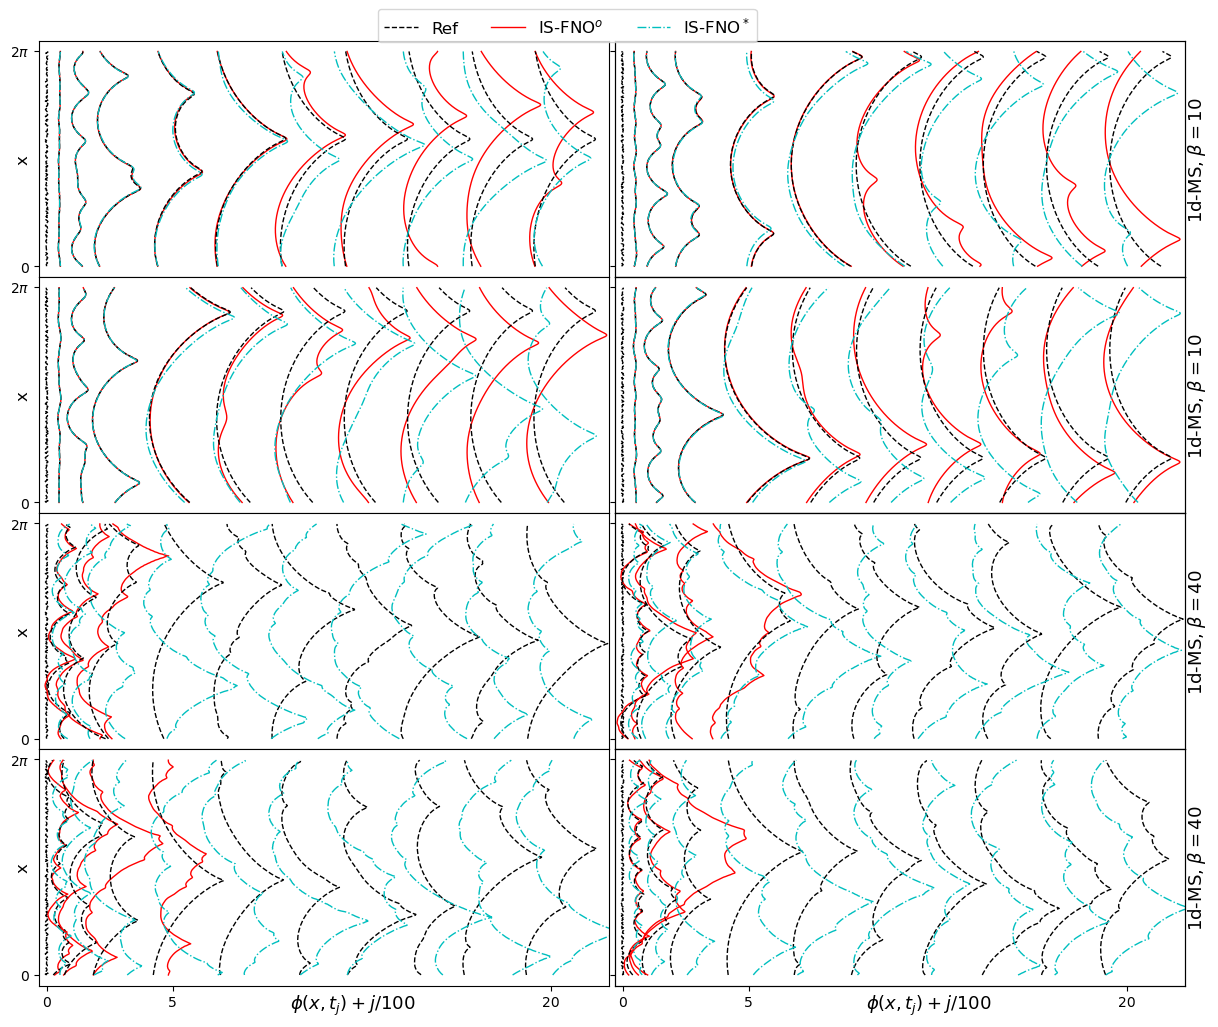

In [20]:
list_i_t_plot = [0,            50 ,  125  ,250  ,500   ,750 , 1000 ,1250,1500,1750,2000]
para_name,  list_init, nStep, Tout,T_in, png_filename  =  'Lpi_rho',  [6,7], 1,  20,1, None 
list_init = [1,2,4,5]
All_list_para_values =[ [10,1],  [40,1]   ] 
All_list_model_names =[ ['RevtFNO101_n', 'RevtFNO101'  ],  ['RevtFNO401_n', 'RevtFNO401' ]    ] #,'tFNO101_k1'

png_filename =  'MS_isFNO.eps' 
#
plot_disp_long(All_list_model_names, para_name, All_list_para_values, list_init, nStep, Tout, T_in, png_filename ,  models= models, list_i_t_plot=list_i_t_plot, SR_ratio=1 )


run2_RevtFNO_m128w30Lpi_rho10_0_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =722531
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
rand_d0_simple, scale= 0.1
RK4NumericalSolver_usol: large t.size=( 2001 ); a single-dot is printed for 1000 steps
..d_an.shape= (2001, 256)
RK4NumericalSolver_usol: large t.size=( 2001 ); a single-dot is printed for 1000 steps
..d_an.shape= (2001, 256)
RK4NumericalSolver_usol: large t.size=( 2001 ); a single-dot is printed for 1000 steps
..d_an.shape= (2001, 256)
RK4NumericalSolver_usol: l

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


savefig:  KS_isFNO.eps


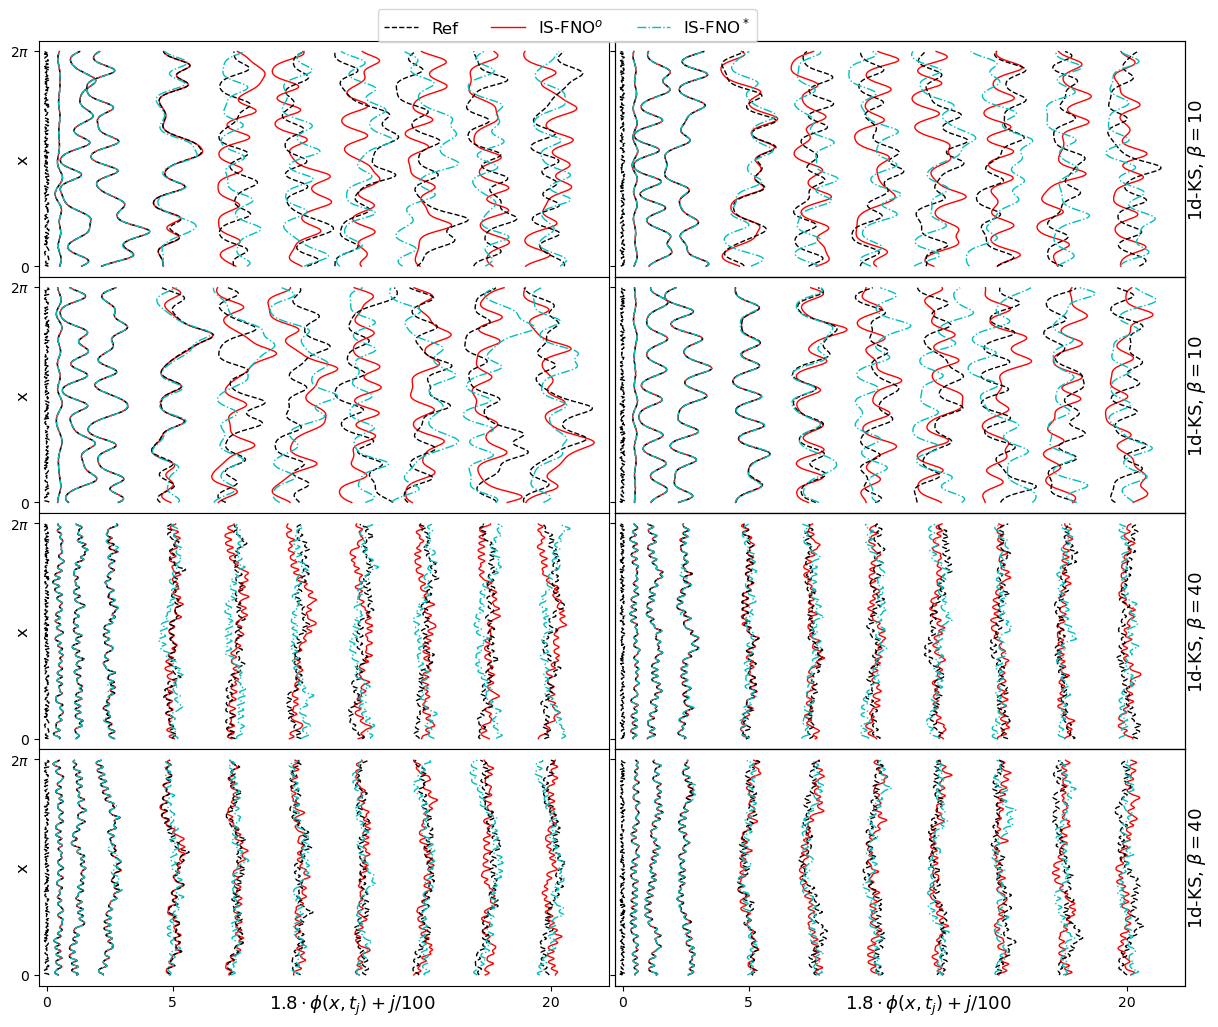

In [21]:
list_i_t_plot = [0,            50 ,  125  ,250  ,500   ,750 , 1000 ,1250,1500,1750,2000]
para_name,  list_init, nStep, Tout,T_in, png_filename  =  'Lpi_rho',  [6,7], 1,  20,1, None 
list_init = [0,2,3,4]
All_list_para_values =[   [10,0] , [40,0]] 
All_list_model_names =[  ['RevtFNO100_n', 'RevtFNO100'  ],  ['RevtFNO400_n', 'RevtFNO400'  ] ] # ,,'tFNO100_k1', 'tFNO400_k1' 

png_filename =  'KS_isFNO.eps' 
#
plot_disp_long(All_list_model_names, para_name, All_list_para_values, list_init, nStep, Tout, T_in, png_filename ,  models= models, list_i_t_plot=list_i_t_plot, SR_ratio=1.8 )


In [22]:
list_i_t_plot = [0,            50 ,  125  ,250  ,500   ,750 , 1000 ,1250,1500,1750,2000]
para_name,  list_init, nStep, Tout,T_in, png_filename  =  'Lpi_rho',  [6,7], 1,  20,1, None 
list_init = [1,2]
All_list_para_values =[ [40,1] , [40,0], [10,1], [10,0] ]
All_list_model_names =[ ['RevtFNO401_n','RevtFNO401' ],['RevtFNO400_n', 'RevtFNO400'  ],['RevtFNO101_n', 'RevtFNO101'  ],['RevtFNO100_n', 'RevtFNO100' ],   ]

png_filename =  None #'siva_isFNO.eps' 
#
#plot_disp_long(All_list_model_names, para_name, All_list_para_values, list_init, nStep, Tout, T_in, png_filename ,  models= models, list_i_t_plot=list_i_t_plot )


In [23]:
def plot_para_len (all_list_models_for_cmp, all_list_init,  png_filename=None, ylim=(0.9,2.1) , models= models ):

    num_steps_for_plot= 2000
    nRow_per_init = 1 #
    
    fig, axs = plt.subplots(nRow_per_init*len( all_list_models_for_cmp[0] ),len(all_list_init),sharex=True, sharey=True,figsize= [12,1.3*len(all_list_models_for_cmp[0])*nRow_per_init ])

    for idx_ , list_models_for_cmp in enumerate(all_list_models_for_cmp):
        for  i_nu, models_for_cmp in enumerate(list_models_for_cmp):
            #---
            nSkip_all   = [ m_['nStep'] for m_ in models_for_cmp]
            m_all       = [ get_model(**m_ , models= models ) for m_ in models_for_cmp]

            #---
            each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
            pred_all          = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ]     
            #---

            len_an_all       = m_all[0]['sys'][each_para_key_all[0]+'list_NormalizedTotalLen_an']
            len_pred_all = [ m_[each_para_key_all[idx]+'list_NormalizedTotalLen_pred'] for idx, m_ in enumerate(m_all) ] 


            #----------------------
            list_plot_style = ['-r','-.b',':c','--g', ':m',':b']
            #--------------------------------------------------------------------
            #list_legend =['Ref'] +  ['$'+ m['name'] + '$' for m in models_for_cmp ]
            list_legend =['Ref'] +  [ alias_to_lengend_txt(m['name'])  for m in models_for_cmp ]

            #for  idx_, ax  in enumerate( axs[i_nu*nRow_per_init:(i_nu+1)*nRow_per_init,: ].reshape(-1) ):
            ax = axs[i_nu,idx_ ]
            ################################
            i_d0 = all_list_init[idx_][0]

            ax.set_yticks( [ 1, 1.5, 2 ] )
            ax.set_yticklabels(['1', '1.5' , '2'], rotation='vertical',  fontsize=12 )
            ax.set_xticks( [ 0,  500, 1000, 2000] )
            ax.set_xticklabels(['0','500', '1000' ,'2000'], fontsize=12)
            ax.set_xlabel( 't/0.15', fontsize=13) 
            
            ax.set_ylim(*ylim)


            len_an = len_an_all[i_d0]
            nnn=np.arange( num_steps_for_plot+1)

            ax.plot( nnn, len_an[:num_steps_for_plot+1],'--k' , lw=1)
            list_len_pred = [ len_[i_d0] for len_ in  len_pred_all ] 

            for idx, len_pred in enumerate( list_len_pred):
                nnn = np.arange( num_steps_for_plot // nSkip_all[idx] + 1 ) *nSkip_all[idx]
                ax.plot(nnn, len_pred[:num_steps_for_plot+1], list_plot_style[idx] , lw=1)

                #ax.plot(  len_pred, '-r' )
                #ax.plot(  len_pred1, '-.c' )
                #ax.plot(  len_predC, '--g' )
                #ax.plot(  len_pred1C, '--m' )
            
            #ax.legend(list_legend , ncol=2,  loc='lower right', fontsize=10)
            if i_nu==0 and idx_== len(all_list_init)-1:
                ax.legend(list_legend , ncol=2,  loc='upper right', fontsize=12, frameon=True, borderpad=0,labelspacing=0.1)
                
                #ax.set_title(r'$\beta={:g}$'.format(models_for_cmp[0]['each_para_value'][0] ) , fontsize=14 ) 

            if idx_== len(all_list_init)-1: 
                #ax2 = ax.twinx()
                ax.yaxis.set_label_position("right")
                para = models_for_cmp[0]['each_para_value']
                
                #list_RightText =  r"$\beta={:g},\rho={}$".format(para[0], Fraction(para[1]) )
                list_RightText =  r"$\rho={}$".format(Fraction(para[1]) )
                
                #txt_instablity = 'DL' if para[1]==1  else 'DT' 
                #list_RightText =   txt_instablity + r', $\rho$={}'.format( para[0])

                #list_RightText =  r"$\rho={}$".format( Fraction(para[1])   )
                ax.set_ylabel(list_RightText,  fontsize=14  )
                #ax2.set_yticks([])                
            ########################################################

    #plt.subplots_adjust(left=0.045, right=0.98, top=0.99, bottom=0.13, wspace=0.02, hspace=0.02)
    plt.subplots_adjust(left=0.053, right=0.975, top=0.975, bottom=0.08, wspace=0.02, hspace=0.02)
    #fig.text(0.4, 0.001, 't/0.015', ha='center',fontsize=14)
    fig.text(0.001, 0.52, r'Normalized total front length ,    $\int (\phi_x^2 +1 )^{1/2} dx /(2\pi) $', va='center', rotation='vertical',fontsize=14 )

    # para_list = [ models_for_cmp[0]['each_para_value'] for models_for_cmp in list_models_for_cmp]
    # list_RightText = [ r"$\beta={:g},\rho={}$".format(para[0], Fraction(para[1]) )    for para in para_list[::-1]]
    # dy =(1-0.05)/len(para_list)/nRow_per_init
    # for idx in range( nRow_per_init*len(para_list) ):
    #     ypos = 0.01+(0.5+idx)*dy
    #     fig.text(0.98, ypos, list_RightText[idx//nRow_per_init],  rotation='vertical',fontsize=12 ,transform=plt.gcf().transFigure) #, weight='bold')
    #---------------------
    if png_filename is not None:
        print('savefig: ', png_filename)
        if 'eps' in png_filename:
            plt.savefig(png_filename, format='eps')
        else:
            plt.savefig(png_filename, dpi=300)            


In [24]:
all_list_init = [ [0], [1] ] #,[2] ,[4] ]  
# all_list_para_values =[ [25,1],    [25,0.75],              [25,0.5],                   [25,0.25],                      [25,0]   ]
# all_list_model_names =[ [ 'tFNO251',  'tFNO251_k1' ],
#                         ['tFNO25075', 'tFNO25075_k1' ],
#                         ['tFNO2505',  'tFNO2505_k1' ],
#                         ['tFNO25025', 'tFNO25025_k1' ],
#                         ['tFNO250',   'tFNO250_k1' ],  ]

all_list_para_values =[ [40,1] , [40,0], [10,1], [10,0] ]
all_list_model_names =[ ['RevtFNO401_n', 'RevtFNO401' ],#  , 'RevtFNO401'],
                        ['RevtFNO400_n', 'RevtFNO400' ],#  , 'RevtFNO400' ],
                        ['RevtFNO101_n', 'RevtFNO101' ],#  , 'RevtFNO101'],  
                        ['RevtFNO100_n', 'RevtFNO100' ] ] # , 'RevtFNO100'],]


# all_list_model_names =[  ['kFNO401','kFNO401_k1'], 
#                          ['kFNO101','kFNO101_k1'], 
#                          ['kFNO400','kFNO400_k1'],
#                          ['kFNO100','kFNO100_k1']  ]

all_list_models_for_cmp =[ 
                         [ [{'name':model_name, 'para_name':'Lpi_rho','each_para_value': para_value ,'nStep':1,'Tout':20} 
                         for model_name in list_model_names     ] 
                         for list_model_names, para_value in zip(all_list_model_names, all_list_para_values) ]
                         for j,_  in enumerate(all_list_init)     ]
#------------------------------------

#png_filename = None #  'len_tNO.eps'
png_filename = None # 'len1d_beta25.eps'

# plot_para_len ( all_list_models_for_cmp, all_list_init , png_filename, ylim=(0.98,2.1), models= models)


In [25]:
def autocorr4(x,lags):
    '''fft, don't pad 0s, non partial'''
    mean=x.mean(axis=-1, keepdims=True)
    #var=np.var(x, axis=-1, keepdims=True)
    xp=x-mean

    cf=np.fft.fft(xp)
    sf=cf.conjugate()*cf
    corr=np.fft.ifft(sf).real/x.shape[-1] #/var

    return corr[..., :lags]


In [26]:
def plot_para_autocorrelation(All_list_models_for_cmp ,   png_filename=None, models= models, bAutoCorr=False, n_steady = 1000, ylim=None) : # 


    marker = [  's', None, None, 's']
    markevery =  [15,1,1,1]
    linestyle= [ ':' ,'--', '-.', '-.']
    color = ['c', 'b', 'r' , 'g']

    nRows = len(All_list_models_for_cmp)
    nCols = len(All_list_models_for_cmp[0][0])

    fig, axs = plt.subplots( nRows,  nCols,sharex=True, sharey=True,figsize= [12/1.2, 4.5*len(All_list_models_for_cmp)])

    axs=axs.reshape(nRows, nCols ) 
    
    for irow_ , list_models_for_cmp in enumerate(All_list_models_for_cmp):
        
        list__nStep_all       =[]
        list__m_all           = []
        list__each_para_key_all=[]
        list__pred_all          =[]
        for models_for_cmp in list_models_for_cmp:
            #print ('models_for_cmp=', models_for_cmp)
            #-------
            nStep_all = [    m_['nStep'] for m_ in models_for_cmp] 
            m_all     = [ get_model(**m_ , models= models) for m_ in models_for_cmp]
            each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
            pred_all = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ] 
            #------
            list__pred_all.append(pred_all )


        #---------------        
        x = m_all[0]['x']
        N = m_all[0]['sys']['N']

        levels= np.linspace(-1,1,20)
        cmap= 'rainbow'

        #-----------
        N_end =num_total_step
        def get_yy_xx(nStep,x=x, N_end = N_end, N_corr=N//2 ):
            y = np.arange(num_total_step//nStep+1) * nStep
            xx,yy = np.meshgrid(x,y,indexing='xy')
            return yy[:N_end, :N_corr],xx[:N_end, :N_corr]


        def calc_autocorrlation(disp, N=N, N_end=N_end, N_corr = N//2 ):
            return autocorr4( disp[:N_end,:], N_corr)
        #------

        nRow = len(models_for_cmp)
        num_models = len(list_models_for_cmp) 



        ####################################################
        xx = np.linspace( 0, np.pi, N//2)
        
        #print(axs.shape)
        for i, ax in enumerate(  axs[irow_,:] ) :
            #-----------
            d_ans     = m_all[0]['sys'][each_para_key_all[i]+'list_d_an']   
            print('d_ans.shape', d_ans.shape)
            #-----------    

            corr_ref = calc_autocorrlation(d_ans)[:,n_steady:,:].mean(axis=(0,1) )

            ax.plot( xx, corr_ref/corr_ref[0]    , color='lightgrey',  linewidth=6  )

            for j in range( num_models ):
                pred_pickplot = list__pred_all[j][i] 

                corr_model_pred = calc_autocorrlation(pred_pickplot)[:,n_steady:,:].mean(axis=(0,1) )
                if bAutoCorr==True:
                    #ax.plot(xx,   corr_model_pred/corr_model_pred[0] , linestyles[j]    )
                    
                    ax.plot(xx,   corr_model_pred/corr_model_pred[0] ,  linestyle=linestyle[j], marker=marker[j], color=color[j],markevery=markevery[j]   )
                else:
                    ax.plot(xx,   corr_model_pred/corr_ref[0]            ,linestyle=linestyle[j], marker=marker[j], color=color[j],markevery=markevery[j]   )


            if irow_==0:


                str_prefix = '1d-MS, ' if  models_for_cmp[i]['each_para_value'][1] == 1 else  '1d-KS, '
                str__para_name = str_prefix+ r'$\beta={}$'.format( models_for_cmp[i]['each_para_value'][0]) 
                
                ax.set_title(str__para_name, fontsize=18)

            if i== 0:
                
                txt_legends = ['Ref']+ [ alias_to_lengend_txt(models_for_cmp[0]['name']) for models_for_cmp in list_models_for_cmp] 
                ax.legend(txt_legends, fontsize=16,  frameon=True, borderpad=0,labelspacing=0.1)

    
            #-----------    

    for ax in axs.flat:
        #ax.set_rasterized(True)
        ax.set_ylabel('Auto-correlation',  fontsize=18  )
        ax.label_outer()
        ax.set_xlim( [0,np.pi+0.1])
        #ax.set_ylim( [-1, 1] )
        ax.set_xticks( [0,   np.pi] )
        ax.set_xticklabels(['0',  '$\pi$'  ] , fontsize=14 )
        
        ax.set_xlabel('r',  fontsize=18  )
        ax.xaxis.set_label_coords(0.5,-0.1)

        
        
        ax.set_yticks( [-1/2, 0,1/2, 1] )
        ax.set_yticklabels(['-0.5', '0','0.5','1' ] , fontsize=14 )

        if ylim is not None:
            ax.set_ylim( ylim )
        
    fig.tight_layout( )
    plt.subplots_adjust(wspace=0.05) #, hspace=0.1 )

        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)

tFNO_m128w30Lpi_rho10_0_o20  loaded in: count_learnable_params =700937
Lpi10rho0_list_pred.shape= (40, 2001, 256)
tFNO_m128w30Lpi_rho40_0_o20  loaded in: count_learnable_params =700937
Lpi40rho0_list_pred.shape= (40, 2001, 256)
tFNO_m128w30Lpi_rho10_1_o20  loaded in: count_learnable_params =700937
Lpi10rho1_list_pred.shape= (40, 2001, 256)
run2_tFNO_m128w30Lpi_rho40_1_noskip_o20  loaded in: count_learnable_params =700937
Lpi40rho1_list_pred.shape= (40, 2001, 256)
d_ans.shape (40, 2001, 256)
d_ans.shape (40, 2001, 256)
d_ans.shape (40, 2001, 256)
d_ans.shape (40, 2001, 256)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


save png:  corr_1d_siva_isFNO.eps


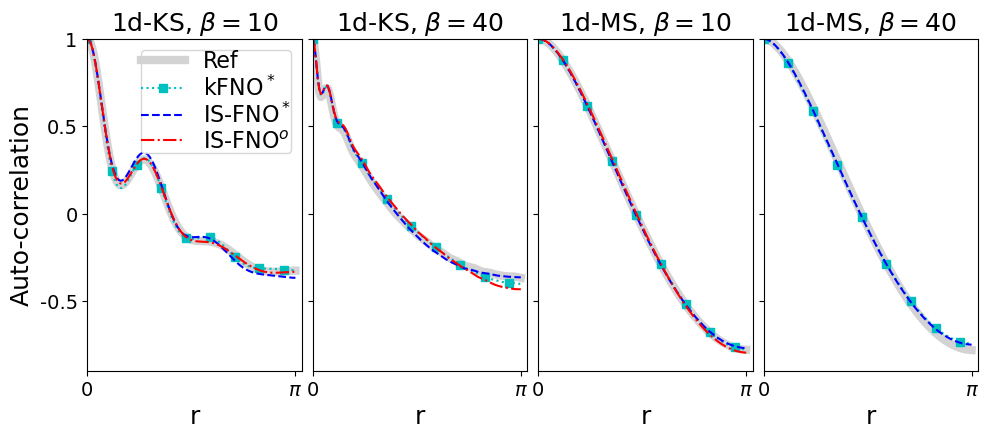

In [27]:
bAutoCorr = True # False


All_list_para_values =[ [[10,0],[40,0],  [10,1], [40,1]  ] ]
#All_list_model_names =[ [ ['RevtFNO100_n', 'RevtFNO100'], # 'RevtFNO100_e',
#                          ['RevtFNO400_n', 'RevtFNO400'], #'RevtFNO400_e'
#                          ['RevtFNO101_n', 'RevtFNO101'], # 'RevtFNO101_e',
#                          ['RevtFNO401_n', 'RevtFNO401'] ] ]   #'RevtFNO401_e',
All_list_model_names =[ [ ['tFNO100', 'RevtFNO100', 'RevtFNO100_n', ], # 'RevtFNO100_e',
                          ['tFNO400', 'RevtFNO400',  'RevtFNO400_n'], #'RevtFNO400_e'
                          [ 'tFNO101', 'RevtFNO101',  'RevtFNO101_n'], # 'RevtFNO101_e',
                          ['tFNO401', 'RevtFNO401',  'RevtFNO401_n' ] ] ]   #'RevtFNO401_e',

All_list_models_for_cmp =     [ 
             [   [ {'name':All_list_model_names[j][i][m_k],'para_name':'Lpi_rho','each_para_value': para_values ,'nStep':1,'Tout':20}  for i, para_values in enumerate(All_list_para_values[j] )   ] 
             for m_k in range(3)] 
             for j in range(1) ]


#-----------------------


png_filename='corr_1d_siva_isFNO.eps'
plot_para_autocorrelation(All_list_models_for_cmp,   png_filename=png_filename, models= models, bAutoCorr = bAutoCorr , ylim=[-0.9,1])

#
    


In [28]:
def plot_errors(list_models_for_cmp ,list_i_pickplot,  png_filename=None, models= models) : # list__i_pickplot__init_d0=[1]

    
    import matplotlib.gridspec as gridspec

    
    
    list__nStep_all       =[]
    list__m_all           = []
    list__each_para_key_all=[]
    list__pred_all          =[]
    for models_for_cmp in list_models_for_cmp:
        #-------
        nStep_all = [    m_['nStep'] for m_ in models_run2_lr1e3for_cmp] 
        m_all     = [ get_model(**m_ , models= models) for m_ in models_for_cmp]
        each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
        pred_all = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ] 
        #------
        list__pred_all.append(pred_all )
        list__each_para_key_all.append(each_para_key_all)
    #-----------
    str__para_name        = r'$\rho$='  
    #str__para_name_legend = [ r'$\beta={},\rho={}$'.format( Fraction(m['each_para_value'][0]), Fraction(m['each_para_value'][1]) )  for m in models_for_cmp ]
    
    str__para_name_legend = [ alias_to_lengend_txt(models_for_cmp[0]['name'])   for models_for_cmp in list_models_for_cmp ]

    print(str__para_name_legend)
    #----------
        
    
    #---------------        
    x = m_all[0]['x']
    N = m_all[0]['sys']['N']
    
    levels= np.linspace(0,0.1,20)
    cmap= 'rainbow'

    #-----------
    N_end = num_total_step+1 #1500
    def get_yy_xx(nStep,x=x, N_end = N_end):
        y = np.arange(num_total_step//nStep+1) * nStep
        xx,yy = np.meshgrid(x,y,indexing='xy')
        #return yy,xx
        return yy[:N_end],xx[:N_end]

    def calc_slope( disp, N=N, N_end=N_end ):
        slope= np.diff(disp,axis=1,append=disp[:,0:1])/(2*np.pi/N)
        return slope[:N_end]
    #------

    nCase = len(models_for_cmp)

    
    num_models = len(list_models_for_cmp) 
    

    num_pickplot = len(list_i_pickplot)

    #fig, axs = plt.subplots(nCase*num_pickplot, num_models ,sharex=True, figsize= [2*num_models ,nCase*1.8*num_pickplot*0.8 ])
    fig, axs = plt.subplots( num_models, nCase*num_pickplot ,sharex=True, figsize= [nCase*1.8*num_pickplot*0.8 , 2*num_models])

    #----------
    
    title_2 =[ alias_to_lengend_txt(models_for_cmp[0]['name'])   for models_for_cmp in list_models_for_cmp ]
    rows = ['{:g}'.format( model['each_para_value'][0] ) for model in models_for_cmp ]
    for ax, t1  in zip(axs[0], title_2):
        ax.set_title( t1, fontsize= 15 , pad=15)

   
    for idx_pick, i_pickplot in enumerate(list_i_pickplot):
        for icase in range(nCase):

            irow = idx_pick*nCase + icase
            ax_rows = axs[:,irow]

            
            for idx, pred_all   in enumerate( list__pred_all  ):
                #-----------
                each_para_key_all = list__each_para_key_all[idx]
                d_an     = m_all[icase]['sys'][each_para_key_all[icase]+'list_d_an'][ i_pickplot ][...,:N_end]
                #-----------    
                
                pred_pickplot =  pred_all[icase][ i_pickplot ][...,:N_end]
                
                pos = ax_rows[idx].contourf( *get_yy_xx(1)    , ((pred_pickplot - d_an)**2/(d_an**2).mean(axis=(-2,-1),keepdims=True))**0.5 , levels = levels ,cmap=cmap  )   
                
            #-----------   
            for idx, ax in enumerate(ax_rows):
                ax.set_yticks( [-np.pi, 0, np.pi] )
                if irow == 0:            ax.set_yticklabels(['-$\pi$', '0', '$\pi$'], fontsize=10,rotation='vertical')
                else:                    ax.set_yticklabels(['-$\pi$', '0', ''], fontsize=10,rotation='vertical')
                ax.set_ylabel('$x$',fontsize=12)
                ax.set_xticks( [0,  50 , 100 ] )
                ax.set_xticklabels(['0','50','100'   ], fontsize=14)
                ax.xaxis.set_tick_params(labelsize=14)
                ax.set_xlabel('$t/0.15$',fontsize=14)
    
                if irow == len(list_i_pickplot)*nCase-1: 
                    ax.yaxis.set_label_position("right")
                    ax.set_ylabel( str__para_name_legend[idx],fontsize=13)
            
    for ax in axs.flat:
        ax.label_outer()
        ax.set_xlim([0,200])

    fig.tight_layout( )
    fig.subplots_adjust(wspace=0.05,hspace=0.05)
    
        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)

In [29]:

All_list_para_values =[  [25,1],    [25,0.75],              [25,0.5],                   [25,0.25],                      [25,0]   ]
All_list_model_names =[  [ 'tFNO251',  'tFNO251_k1' ],
                        ['tFNO25075', 'tFNO25075_k1' ],
                        ['tFNO2505',  'tFNO2505_k1' ],
                        ['tFNO25025', 'tFNO25025_k1' ],
                        ['tFNO250',   'tFNO250_k1' ]   ]



list_models_for_cmp =[ [{'name':All_list_model_names[idx][j], 'para_name':'Lpi_rho','each_para_value': list_para_values ,'nStep':1,'Tout':20} 
                         for idx, list_para_values in enumerate(All_list_para_values) ] 
                         for j in  range(2) ]



#png_filename= None
png_filename=  None # 'err_1D.png'
#plot_errors(list_models_for_cmp,  list_i_pickplot =[0], png_filename=png_filename, models= models)

In [30]:
def plot_compressed_errors(list_models_for_cmp ,line_legend,  png_filename=None, models= models) : 
    import matplotlib.gridspec as gridspec
    import numpy as np
    
    list__nStep_all       =[]
    list__m_all           = []
    list__each_para_key_all=[]
    list__pred_all          =[]
    for models_for_cmp in list_models_for_cmp:
        #-------
        nStep_all = [    m_['nStep'] for m_ in models_for_cmp] 
        m_all     = [ get_model(**m_ , models= models) for m_ in models_for_cmp]
        each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
        pred_all = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ] 
        #------
        list__pred_all.append(pred_all )
        list__each_para_key_all.append(each_para_key_all)
    #-----------
    
    str__para_name = [ '1d-MS'+ r', $\beta$={}'.format( m['each_para_value'][0]) if m['each_para_value'][1]==1  else '1d-KS'+ r', $\beta$={}'.format( m['each_para_value'][0])   for m in models_for_cmp ]

    
    #---------------        
    x = m_all[0]['x']
    N = m_all[0]['sys']['N']
 
    #-----------
    N_end = num_total_step+1 #1500

    #------
    nCase = len(models_for_cmp)
    num_models = len(list_models_for_cmp) 
     
    list_text_legend =[ alias_to_lengend_txt(models_for_cmp[0]['name'])   for models_for_cmp in list_models_for_cmp ]

    fig, axs = plt.subplots(1,nCase ,sharey=True, figsize= [4.5 *2,  1*3] , squeeze=False)
    #----------------
     
    
    for icase in range(nCase):
        for idx, pred_all   in enumerate( list__pred_all  ):
            label = list_text_legend[idx]
            each_para_key_all = list__each_para_key_all[idx]
            
            d_an     = m_all[icase]['sys'][each_para_key_all[icase]+'list_d_an'][ ...,:N_end]
            #-----------    
            pred_pickplot =  pred_all[icase][ ...,:N_end]

            #print(idx,icase, d_an.shape,pred_pickplot.shape)

            y = np.sqrt( (pred_pickplot - d_an)**2/(d_an**2).mean( axis=(-2,-1),keepdims=True ) ) 

            #print(y.shape)
            y1 = y[:20,:,:].mean( axis=(-3,-1), keepdims=False ) 
            y2 = y[20:,:,:].mean( axis=(-3,-1), keepdims=False ) 

            ax0 = axs[0,icase]
            ax1 = axs[0,icase]

            ax0.plot( np.arange(N_end),  y1  , line_legend[idx]  , label =  label  )   
            
    
            ax0.set_title(str__para_name[icase], fontsize=12)
            
            ax1.set_xlabel('$t/\Delta_t$',   fontsize=12)

            #------
            t_End = 390   # 150
            if icase==3 :
                t_End = 100
                
                ax1.set_xticks( [ 1, 25, 50 , 75 ] );    
                ax1.set_xticklabels(['1', '25', '50','75'  ] , fontsize=11 )
            else: 
                ax1.set_xticks( [ 1, 100,  200, 300  ] );    
                ax1.set_xticklabels(['1', '100', '200' ,'300'  ] , fontsize=11 )

            ax0.set_xlim([1,t_End])
            ax1.set_xlim([1,t_End])
            #------
    
        
    for ax in axs.flat:
        ax.label_outer()
        ax.set_yscale('log')
        ax.set_ylim ( [2e-4,0.2] )

    
    axs[0,0].set_ylabel('Error', fontsize = 12)
    lines, labels = axs[ 0,0  ].get_legend_handles_labels()
    fig.legend(lines, labels, ncol=8, fontsize=11,  loc = 'upper center' )
    
    #----------
    fig.tight_layout( )
    fig.subplots_adjust(wspace=0.025,hspace=0.015, top=0.78, bottom=0.16) 

    #---------------
    

        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)    
                    


RevtFNO_m128rm32w30Lpi_rho10_0_tAdvD1_exp_o20  loaded in: count_learnable_params =599523
Lpi10rho0_list_pred.shape= (40, 2001, 256)
RevtFNO_m128w30Lpi_rho40_0_tAdvD1_exp_o20  loaded in: count_learnable_params =599523
Lpi40rho0_list_pred.shape= (40, 2001, 256)
run2_RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_o20  loaded in: count_learnable_params =599523
Lpi10rho1_list_pred.shape= (40, 2001, 256)
RevtFNO_m128w30Lpi_rho40_1_tAdvD1_exp_o20  loaded in: count_learnable_params =599523
Lpi40rho1_list_pred.shape= (40, 2001, 256)
tFNO_m128w30Lpi_rho10_0_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =699077
Lpi10rho0_list_pred.shape= (40, 2001, 256)
tFNO_m128w30Lpi_rho40_0_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =699077
Lpi40rho0_list_pred.shape= (40, 2001, 256)
run3_tFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =699077
Lpi10rho1_list_pred.shape= (40, 2001, 256)
lr5e4_tFNO_m128w30Lpi_rho40_1_tAdvD1_exp_nonlraw_o20  loaded in: count_learnable_par

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


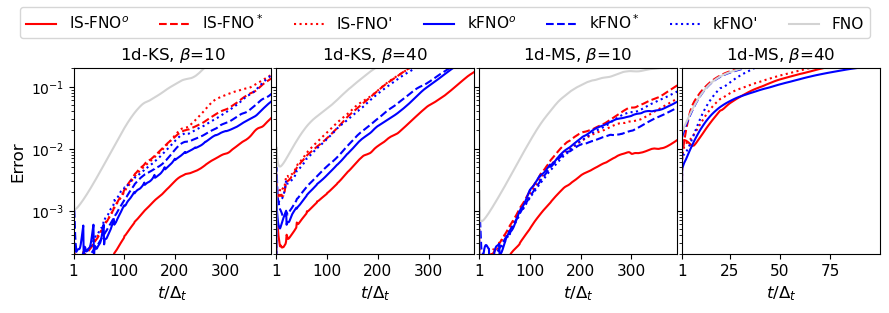

In [31]:
All_list_para_values =[  [10,0], [40,0], [10,1], [40,1] ]
All_list_model_names =[ ['RevtFNO100_n','RevtFNO100','RevtFNO100_e' , 'tFNO100_n', 'tFNO100', 'tFNO100_e','tFNO100_k1' ],
                        ['RevtFNO400_n','RevtFNO400','RevtFNO400_e' , 'tFNO400_n', 'tFNO400', 'tFNO400_e','tFNO400_k1' ], 
                        ['RevtFNO101_n','RevtFNO101','RevtFNO101_e' ,'tFNO101_n', 'tFNO101', 'tFNO101_e' ,'tFNO101_k1'],   #,
                       ['RevtFNO401_n','RevtFNO401','RevtFNO401_e' ,'tFNO401_n', 'tFNO401', 'tFNO401_e' ,'tFNO401_k1' ]  ] #',

line_legend = ['r-', 'r--' , 'r:', 'b-','b--','b:'  ,'lightgrey' ] 


list_models_for_cmp =[ [{'name':All_list_model_names[idx][j], 'para_name':'Lpi_rho','each_para_value': list_para_values ,'nStep':1,'Tout':20} 
                         for idx, list_para_values in enumerate(All_list_para_values) ] 
                         for j in  range( len(All_list_model_names[0]) ) ]


#png_filename= None
png_filename= 'ave_err_siva_1d_isFNO.eps'
plot_compressed_errors(list_models_for_cmp,  line_legend,  png_filename=png_filename, models= models)

In [98]:
#models[-6]['alias']
#models[-6]['model_name_detail']
#
#models[-6]={'alias':'trFNO401'  ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho40_1_noskip_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'}
#models[-6]={'alias':'trFNO401'  ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128rm32w30Lpi_rho40_1_tAdvD1_exp_nonl_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'}


In [99]:
#models[16]=  {'alias':'trFNO101'  ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run3_RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonl_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'}
#models[16]=  {'alias':'trFNO101'  ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128rm32w30Lpi_rho10_1_tAdvD1_exp_nonl_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'}
#models[17]=  {'alias':'trFNO101_e','act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128rm32w30Lpi_rho10_1_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'}


In [100]:
#models=
# [
#   {'alias':'tFNO400_k1','act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
#   {'alias':'tFNO400'   ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },

#   {'alias':'tFNO400_n' ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_tAdvD1_exp_nonl_o20'          ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'tFNO400_e' ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_0_tAdvD1_exp_o20'           ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO400'  ,'act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho40_0_tAdvD1_exp_nonl_o20'     ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO400_e','act_para':[40,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_lr1e3_RevtFNO_m128w30Lpi_rho40_0_tAdvD1_exp_o20'     ,'nStep':1,'Tout':20,'proj_dir':'.'},


#    # ---
#   {'alias':'tFNO100_k1','act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_0_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
#   {'alias':'tFNO100'   ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_0_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },

#   {'alias':'tFNO100_n' ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_0_tAdvD1_exp_nonl_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'tFNO100_e' ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_0_tAdvD1_exp_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO100'  ,'act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128rm32w30Lpi_rho10_0_tAdvD1_exp_nonl_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO100_e','act_para':[10,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho10_0_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},

#   # ---
#   {'alias':'tFNO101_k1','act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_1_o20_k1'  ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
#   {'alias':'tFNO101'   ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_1_o20'     ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
    
#   {'alias':'tFNO101_n' ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_lr1e3_tFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonl_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'tFNO101_e' ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho10_1_tAdvD1_exp_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO101'  ,'act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_nonl_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO101_e','act_para':[10,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho10_1_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},

#   # ---
#   {'alias':'tFNO401_k1','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_1_noskip_o20_k1'    ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023'},
#   {'alias':'tFNO401'   ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_tFNO_m128w30Lpi_rho40_1_noskip_o20'   ,'nStep':1,'Tout':20,'proj_dir':'../ml_paraflame2023' },
  
#   {'alias':'tFNO401_n' ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'lr5e4_tFNO_m128w30Lpi_rho40_1_tAdvD1_exp_nonlraw_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'tFNO401_e' ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO_m128w30Lpi_rho40_1_tAdvD1_exp_o20'    ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO401'  ,'act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'run2_RevtFNO_m128w30Lpi_rho40_1_noskip_o20'  ,'nStep':1,'Tout':20,'proj_dir':'.'},
#   {'alias':'trFNO401_e','act_para':[40,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO_m128w30Lpi_rho40_1_tAdvD1_exp_o20'        ,'nStep':1,'Tout':20,'proj_dir':'.'},
    
# ]

In [262]:
def plot_para_slope(list_models_for_cmp , i_pickplot,  png_filename=None, models= models) : # list__i_pickplot__init_d0=[1]
    #list__i_pickplot__init_d0=[1,3]

    
    list__nStep_all       =[]
    list__m_all           = []
    list__each_para_key_all=[]
    list__pred_all          =[]
    for models_for_cmp in list_models_for_cmp:
        #-------
        nStep_all = [    m_['nStep'] for m_ in models_for_cmp] 
        m_all     = [ get_model(**m_ , models= models) for m_ in models_for_cmp]
        each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
        pred_all = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ] 
        #------
        list__pred_all.append(pred_all )
        
    #-----------
    #str__para_name        = r'$\rho$='  if models_for_cmp[0]['para_name']=='dd' else r'$\beta$=' 
    #str__para_name_legend = [ str__para_name+str(m['each_para_value'])    for m in models_for_cmp ]


    #str__para_name_legend = [ r'$\beta={:g},\rho={}$'.format(m['each_para_value'][0], Fraction( m['each_para_value'][1] ) )     for m in models_for_cmp ] 

    #str__para_name_legend = [ r'$\beta={:g},\rho={}$'.format(m['each_para_value'][0], Fraction( m['each_para_value'][1] ) )     for m in models_for_cmp ] 
    
    str__para_name_legend = [ 'MS'+ r', $\beta$={}'.format( m['each_para_value'][0]) if m['each_para_value'][1]==1  else 'KS'+ r', $\beta$={}'.format( m['each_para_value'][0])   for m in models_for_cmp ]
    
    #----------
        
    # if models_for_cmp2 is not None:
    #     nStep_all2 = [    m_['nStep'] for m_ in models_for_cmp2] 
    #     m_all2     = [ get_model(**m_ , models= models) for m_ in models_for_cmp2]
    #     each_para_key_all2 = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp2] 
    #     pred_all2 = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all2,each_para_key_all2) ] 
    
    #---------------        
    x = m_all[0]['x']
    N = m_all[0]['sys']['N']
    
    #levels= np.linspace(-2.5,2.5,20)
    levels= np.linspace(-3.5,3.5,20)
    cmap= 'rainbow'

    #-----------
    N_end = 2000 # num_total_step #1500
    def get_yy_xx(nStep,x=x, N_end = N_end):
        y = np.arange(num_total_step//nStep+1) * nStep
        xx,yy = np.meshgrid(x,y,indexing='xy')
        #return yy,xx
        return yy[:N_end],xx[:N_end]

    def calc_slope( disp, N=N, N_end=N_end ):
        slope= np.diff(disp,axis=1,append=disp[:,0:1])/(2*np.pi/N)
        return slope[:N_end]
    #------

    nCase = len(models_for_cmp)

    # if models_for_cmp2 is not None:
    #     fig, axs = plt.subplots(nCase, 3 ,sharex=True, sharey=True,figsize= [12,nCase*2*1.25])
    #     cols = ['Ref',  models_for_cmp[0]['name'],  models_for_cmp2[0]['name'] ]
    # else:
    #     fig, axs = plt.subplots(nCase, 2 ,sharex=True, sharey=True,figsize= [12,nCase*2*1.25])
    #     cols = ['Ref',  models_for_cmp[0]['name'] ]
    num_models = len(list_models_for_cmp) 
    fig, axs = plt.subplots(nCase, num_models+1 ,sharex=True, figsize= [12,nCase*1.5*1.25])
    #fig, axs = plt.subplots(nCase, num_models+1 ,sharex=True, sharey=True,figsize= [12,nCase*2*1.25], facecolor = 'aliceblue')
    
    cols = ['Ref'] + [   alias_to_lengend_txt(models_for_cmp[0]['name']) for models_for_cmp in list_models_for_cmp ]

    
    #----------
    #rows = [r"\beta={:g},\rho={:g}".format( model['each_para_value'][0] , model['each_para_value'][1]) for model in models_for_cmp ]
    rows = [r"\rho={:g}".format(  model['each_para_value'][1]) for model in models_for_cmp ]

    for ax, col in zip(axs[0], cols):
        #ax.set_title('$'+col+'$', fontsize=14)
        ax.set_title(col, fontsize=12)

#     pad = 5 # in points
#     for ax, row in zip(axs[:,0], rows):
#         #ax.set_ylabel(row, rotation=90, size='large')
#         ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#                     xycoords=ax.yaxis.label, textcoords='offset points',
#                     size='large', ha='right', va='center')
        
    #----------
    
    for icol, ax_cols in enumerate(  axs ) :
        
        #i_pickplot = list__i_pickplot__init_d0[icol]
        #-----------
        d_an     = m_all[icol]['sys'][each_para_key_all[icol]+'list_d_an'][ i_pickplot ]
        #-----------    
        ax_cols[0].contourf( *get_yy_xx(1)    , calc_slope(d_an)          , levels = levels ,cmap=cmap  )

        for idx, pred_all in enumerate(list__pred_all):
            pred_pickplot =  pred_all[icol][ i_pickplot ]
            ax_cols[idx+1].contourf( *get_yy_xx(1)    , calc_slope(pred_pickplot) , levels = levels ,cmap=cmap  )   
        #-----------    
 
        # if models_for_cmp2 is not None:
        #     pred_pickplot2 =  pred_all2[icol][ i_pickplot ]
        #     ax_cols[2].contourf( *get_yy_xx(1)    , calc_slope(pred_pickplot2) , levels = levels ,cmap=cmap  )   
                
        for idx, ax in enumerate(ax_cols):
            
            if icol == 0:  
                ax.set_yticks( [-np.pi, 0, np.pi] )
                ax.set_yticklabels(['0', '$\pi$', '2$\pi$'], fontsize=12,rotation='vertical')
            else:
                ax.set_yticks( [-np.pi, 0] )
                
                ax.set_yticklabels(['0',  '$\pi$'], fontsize=12,rotation='vertical')
            ax.set_ylabel('$x$',fontsize=12)
            
            #ax.set_xticks( [ 0,100,200,300,400 , 500] )
            #ax.set_xticklabels(['0','100','200','300','400','500'], fontsize=13)
            #ax.xaxis.set_tick_params(labelsize=12)
            ax.set_xlabel('$t/0.15$',fontsize=12)

            if idx == len(ax_cols)-1: 
                ax.yaxis.set_label_position("right")
                ax.set_ylabel( str__para_name_legend[icol],fontsize=12)
            
    for ax in axs.flat:
        ax.label_outer()
        #ax.set_xlim([0,2000])
        
    fig.tight_layout(  )
    plt.subplots_adjust(wspace=0.01,hspace=0.01)

    #fig.text(0.465, 0.001, 't/0.015', ha='center',fontsize=16)
    #fig.text(0.001, 0.52, 'x', va='center', rotation='vertical',fontsize=14 )

    #----
    # str__para_name = r'$\nu$='  if models_for_cmp[0]['para_name']=='nu' else r'$\mathcal{L}$=' 
    # list_legend = [  m['each_para_value'] for m in models_for_cmp ]
    # dy =(0.95-0.05)/len(list_legend)
    # for idx, legend_text in enumerate(list_legend[::-1]):
    #     ypos = 0.05+(0.5+idx)*dy
    #     #fig.text(0.985, ypos, legend_text,  rotation='vertical',fontsize=14 ,transform=plt.gcf().transFigure, weight='bold')
    #     fig.text(0.9905, ypos, str__para_name+str(legend_text),  rotation='vertical',fontsize=13 ,transform=plt.gcf().transFigure) #, weight='bold')
    #---    
    #fig.tight_layout()
    #plt.subplots_adjust(wspace=0.01,hspace=0.01)
        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)
        

save png:  siva_1d_slope.png


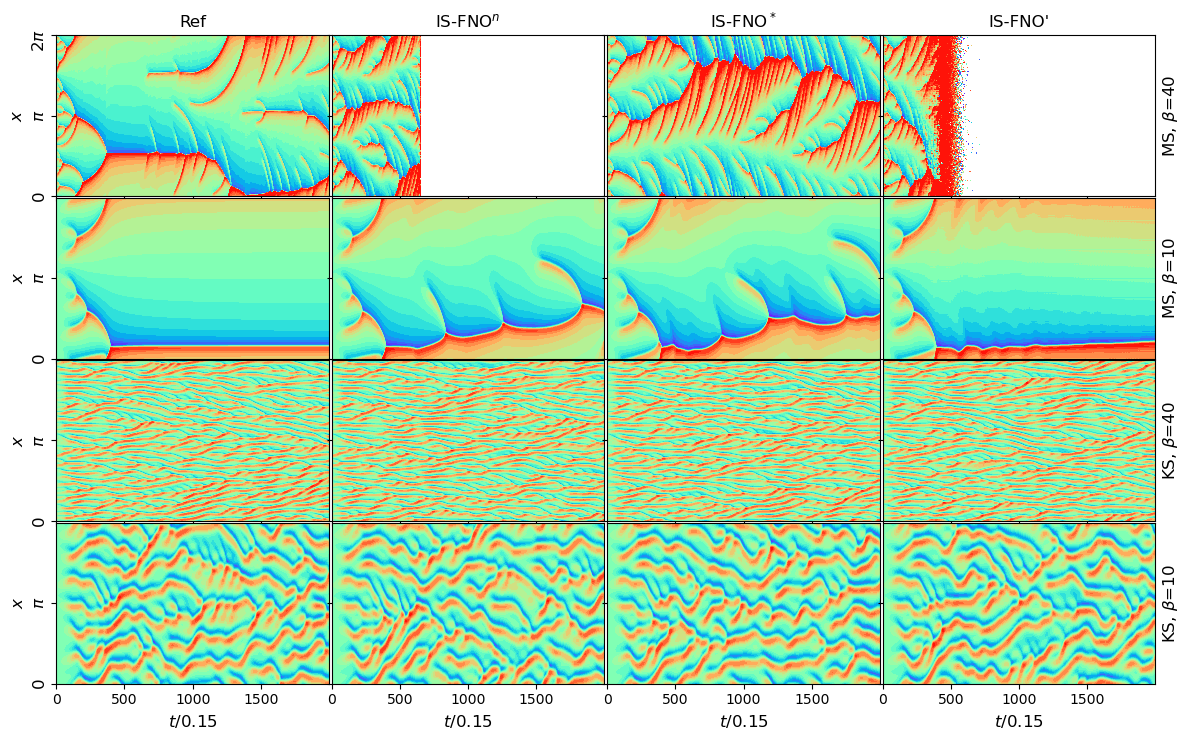

In [264]:
list_para_values =[ [40,1] ,[10,1], [40,0],  [10,0] ]
All_list_model_names =[ ['RevtFNO401_n', 'RevtFNO401', 'RevtFNO401_e' ],
                     ['RevtFNO101_n', 'RevtFNO101', 'RevtFNO101_e'],
                       ['RevtFNO400_n','RevtFNO400', 'RevtFNO400_e' ],
                     ['RevtFNO100_n','RevtFNO100', 'RevtFNO100_e']   ]

# list_para_values =[ [25,1] ,[10,1], [25,0],  [10,0] ]
# All_list_model_names =[ ['RevtFNO251_n', 'RevtFNO251', 'RevtFNO251_e' ],
#                      ['RevtFNO101_n', 'RevtFNO101', 'RevtFNO101_e'],
#                        ['RevtFNO250_n','RevtFNO250', 'RevtFNO250_e' ],
#                      ['RevtFNO100_n','RevtFNO100', 'RevtFNO100_e']   ]


list_models_for_cmp =[ [{'name':All_list_model_names[idx][j], 'para_name':'Lpi_rho','each_para_value': para_value ,'nStep':1,'Tout':20} 
                        #for  model_name in list_model_names ]
                         for idx, para_value in enumerate(list_para_values)    ]
                         for j in range(3) ]

png_filename=  'siva_1d_slope.png'  #'uSlope_MKS_beta40.png'

plot_para_slope(list_models_for_cmp, i_pickplot=2, png_filename=png_filename , models= models)



In [ ]:

from scipy.optimize import fsolve
def _func_( b_c_eps_sigma, rho, beta, nu, mu ):
    b,c,eps,sigma = b_c_eps_sigma
    b2=b**2
    c2=c**2
    return [(b/c) - beta ,
             eps/c2 - nu,
            (1-sigma)*(b*c)-rho,
            4*(1+eps)**2/b2-mu*c2**2 ]

b_c_eps_sigma0_dict = { 0:[ 15, 0.38, 6.7, 1 ], 1:[ 9.27, 0.33 ,2 , 0.82 ] , 2:[7.3, 0.182 , 1.72 , 0.62 ], 3:[12.7, 0.3 , -4.4 , 0.81 ], 4: [40, 1, -1, 0.975 ] }    


def dispersion_relation(png_filename=None):
    kk = np.arange(128+1);
    
    #import matplotlib.gridspec as gridspec    
    
    fig = plt.figure( figsize=(16,4))

    #gs0 = gridspec.GridSpec(2, 7, figure=fig)
    #ax = fig.add_subplot(gs0[:,:3])

    ax = plt.subplot2grid((2, 7), (0, 0),  colspan=3, rowspan=3)
    ax1 = plt.subplot2grid((2, 7), (0, 5),  colspan=2, rowspan=1)
    ax12 = plt.subplot2grid((2, 7), (1, 5),  colspan=2, rowspan=1)    
    ax2 = plt.subplot2grid((2, 7), (0, 3),  colspan=2, rowspan=1)
    ax22 = plt.subplot2grid((2, 7), (1, 3),  colspan=2, rowspan=1)    
    
    colors=['r','g', 'orange', 'c' ,'k']
    for idx, Lpi in enumerate( [40] ):
        
        linestyle = '-' if idx==0 else '-.'
        
        for idc, d_ratio in enumerate( [0, 0.25,  0.5, .75 , 1 ] ):
            k = kk/Lpi;
            mu,nu, tau = libSiva.Coeff_Lpi_d_to_mu_nu_tau(Lpi, d_ratio, max_amplitude=0.25 )
            #print('Lpi:',Lpi, ' mu:', mu, 'nu:', nu, 'd_ratio:', d_ratio, 'tau:', tau)

            disp_relation = -(mu* k**4   - nu* k**2- d_ratio*k );
            if np.isclose(mu,0): mu =0
            if np.isclose(nu,0): nu =0
            if np.isclose(nu,1): nu =1
            if np.isclose(nu,-1): nu =-1
            

            my_label = r"$ \rho={} \:(\mu={:.2g}, \nu={:.2g})$".format(Fraction(d_ratio),mu, nu )
            #ax.plot( kk[np.where(kk<Lpi+1)], disp_relation[np.where(kk<Lpi+1) ], '-' , label= my_label )
            
            ax.plot( kk[np.where(kk<Lpi+10)]/Lpi, disp_relation[np.where(kk<Lpi+10) ], linestyle, color=colors[idc] , label= my_label )
    
    ax.set_ylabel(r'$ \omega(\kappa) /\tau  $', fontsize=15)
    ax.set_xlabel(r'$  \kappa /\beta  $', fontsize=15)
    ax.set_yticks([ 0,1/8, 1/4, ], ['0', '1/8','1/4']  )
    ax.set_xlim([0, 1.05])
    ax.set_ylim([-1/32,1/4+1/128])
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    
    
    ax.yaxis.set_ticks_position('both')
    
    #ax.axhline(0,linestyle='-.', color='grey',linewidth=0.5)
    ax.legend(fontsize=12.5,  ncol=1 )
    
    #-----------------------------
    #-----------------------------
    #-----------------------------
    

    N=5

    list_Lpi =np.linspace(10,40,3)
    list_rho= np.linspace(0,1,N)
    list_b = np.zeros(N) 
    list_c = np.zeros(N) 
    list_eps = np.zeros(N) 
    list_sigma = np.zeros(N) 



    my_linestyle=[ 'k:<', 'k--s', 'k-*']
    for idx_Lpi, Lpi in enumerate(list_Lpi):
        for idx_rho,  rho in enumerate(list_rho):
            mu,nu, tau = libSiva.Coeff_Lpi_d_to_mu_nu_tau(Lpi, rho, max_amplitude=0.25 )

            func = lambda b_c_eps_sigma: _func_( b_c_eps_sigma, rho, Lpi, nu, mu )
            root = fsolve(func, b_c_eps_sigma0_dict[idx_rho] )
            b,c,eps,sigma = root
            #print(rho,Lpi, b,c,eps,sigma0 )
            list_b[idx_rho], list_c[idx_rho], list_eps[idx_rho], list_sigma[idx_rho]= b,c,eps,sigma

            if not any(np.isclose(func(root), [0, 0, 0, 0])) : print('error')

        strlabel = r'$\beta={:g}$'.format(Lpi)

        ax1.plot( list_rho, list_b,  my_linestyle[idx_Lpi], label=  strlabel)    
        ax12.plot( list_rho, list_c,     my_linestyle[idx_Lpi] , label= strlabel )    
        ax1.set_ylabel(r'$b$',fontsize=16)
        #ax1.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'])
        ax1.set_xticks([])
        ax1.tick_params(axis='y', labelsize=13)
        ax1.yaxis.set_ticks_position('both')
        
        ax12.set_ylabel(r'$c$',fontsize=16)
        ax12.set_xlabel(r'$\rho$',fontsize=16)
        ax12.tick_params(axis='y', labelsize=13)
        ax12.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'], fontsize=14)
        ax12.yaxis.set_ticks_position('both')

        ax2.plot( list_rho, list_eps, my_linestyle[idx_Lpi] , label=  strlabel)    
        ax2.set_ylabel(r'$Le^*$',fontsize=16)
        ax2.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'])
        ax2.tick_params(axis='y', labelsize=13)
        ax2.yaxis.set_ticks_position('both')
        ax2.set_xticks([])
        
        ax22.plot( list_rho, 1/list_sigma,  my_linestyle[idx_Lpi] , label= strlabel )    
        ax22.set_ylabel(r'$1/\Omega$',fontsize=16)
        ax22.set_xlabel(r'$\rho$',fontsize=16 )
        ax22.tick_params(axis='y', labelsize=13)
        ax22.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'], fontsize=14)
        ax22.yaxis.set_ticks_position('both')


    
    ax1.legend( fontsize=12.5 , ncol=2)
    fig.tight_layout()
    
    #---------------------------------
    
    if png_filename is not None:
        #ax.set_rasterized(True)
        print('savefig: ', png_filename)
        if 'eps' in png_filename:
            plt.savefig(png_filename, format='eps' )
        else:
            plt.savefig(png_filename, dpi=300)    
#dispersion_relation('dRel_ana.eps')

In [25]:
ra_cx = 0.01* torch.ones(1,256)
n = ra_cx.shape[-1]//2
zero_pad =  torch.zeros (  *ra_cx.shape[:-1], 1).to(ra_cx.device)
length   = ra_cx[...,:n+1]
angle    = torch.cat( [ zero_pad,  ra_cx[...,n+1:], zero_pad] , dim =-1)
cx  = length.unsqueeze(-1)*torch.stack([torch.cos( angle), torch.sin( angle)], dim=-1)

In [26]:
#------------------
# def my_irfft( ra_cx ):  # rx.shape = 1, 256
#     n = ra_cx.shape[-1]//2
#     zero_pad =  torch.zeros (  *ra_cx.shape[:-1], 1).to(ra_cx.device)
#     length   = ra_cx[...,:n+1]
#     angle    = torch.cat( [ zero_pad,  ra_cx[...,n+1:], zero_pad] , dim =-1)
#     cx  = length.unsqueeze(-1)*torch.stack([torch.cos( angle), torch.sin( angle)], dim=-1)    
#     return torch.fft.irfft( torch.view_as_complex(cx) )
# def my_rfft(x):
#    cx = torch.fft.rfft( x ,dim=-1)
#    ra_cx = torch.cat( [cx.abs(), cx.angle()[...,1:-1] ], dim=-1)
#    return ra_cx

def my_irfft( rx ):  # rx.shape = 1, 256//2+1 
   return torch.fft.irfft( rx )
def my_rfft(x):
   cx = torch.fft.rfft( x, dim=-1)
   return cx.abs()                # shape 256//N+1

def my_model( ra_cx,  para_value  , model, x_steady = 0 ):
    
    x = my_irfft( ra_cx ).unsqueeze(-1)
    
    #x = x + x_steady.to(x.device)
    #pdepara = torch.tile( torch.tensor( para_value,dtype=torch.float), (1,1) ).to(device) 

    if para_value is None:
        y = model(  x )
    else:
        pdepara = torch.tensor([[ para_value ]], dtype=torch.float).to(device) 
        y = model(  x,  pdepara)
 
    
    #y = y.view( *y.shape[:-1] )   # remove the last dimention
    
    if y.ndim == x.ndim :
        y = y[...,-1]                  # remove the last dimention
    elif y.ndim > x.ndim :
        y = y[...,0,-1]
        
    ra_cy = my_rfft( y )
    
    return ra_cy


#
#all_list_model_names = [ ['pFNO*','pCNN10'] ,['pFNO*'] , ['pFNO*','pCNN40'] ]
#list_models = [model_search['model']  for model_search in models for model_alias in list_model_names if  model_search['alias'] == model_alias ]     
#
def calc_dispersion_relation_for_models(all_list_model_names, list_Lpi, List_rho  ): 

    MaxNum_model = len(all_list_model_names[0])
    dispersion_relation_models  = np.zeros( ( MaxNum_model, len(list_Lpi), len(list_rho), 256//2+1           ) )
    jacobian_all                = np.zeros( ( MaxNum_model, len(list_Lpi), len(list_rho), 256//2+1 ,256//2+1 ) )

    for idx_Lpi, list_model_names  in enumerate( all_list_model_names):
        
        Lpi = list_Lpi[idx_Lpi]   # For AI-fluid , this is fix to be Lpi==25
        
        #----
        x_perturb = 1E-2
        rx = x_perturb* torch.ones(1,256//2+1).to(device)

        for idx_rho, rho in enumerate(list_rho):
            for idx_model, model_names in enumerate(list_model_names):
                #------------------------------------------------
                model = None
                nOutStep_Koopman = 20
                for model_search in models:
                    if np.isclose( rho, model_search['act_para'][-1] ): 
                        if model_names == 'FNO' and '_k1' in model_search['alias']:
                            model = model_search['model'] 
                            nOutStep_Koopman = 1
                        elif model_names == 'kFNO'and '_k1' not in model_search['alias']:
                            model = model_search['model'] 
                            nOutStep_Koopman = 20
                #------------------------------------------------
            
                jacobian_now = torch.autograd.functional.jacobian(lambda t_: my_model(t_, None, model), rx)
                #jacobian_now = torch.autograd.functional.jacobian(lambda t_: my_model(t_, [Lpi,rho], model), rx)
                
                #print(jacobian_now.shape) 
                
                my_jac =  jacobian_now[0,:,0,:].detach().cpu()

                jacobian_all[idx_model,idx_Lpi,idx_rho,:,:] = my_jac

                dispersion_relation_models[idx_model,idx_Lpi,idx_rho, :] = np.log(np.diag( my_jac[:,:]  ) )/(0.15*nOutStep_Koopman)  # 0.15 is time step
                dispersion_relation_models[idx_model,idx_Lpi,idx_rho, 0] = 0

    return dispersion_relation_models, jacobian_all

def ananlytical_dispersion_relation(  list_Lpi, List_rho ):
    kk = np.arange(128+1);
    disp_rel = np.zeros( ( len(list_Lpi), len(list_rho) , 129)  )
    for idx_Lpi, Lpi in enumerate(list_Lpi):
        for idx_rho, d_ratio in enumerate(list_rho):
            k = kk/Lpi;
            mu,nu, tau = libSiva.Coeff_Lpi_d_to_mu_nu_tau(Lpi, d_ratio, max_amplitude=0.25 )
            disp_relation = -(mu* k**4   - nu* k**2- d_ratio*k );
            if np.isclose(mu,0): mu =0
            if np.isclose(nu,0): nu =0
            if np.isclose(nu,1): nu =1
            if np.isclose(nu,-1): nu =-1
            disp_rel[idx_Lpi,idx_rho, :] =  (tau)*disp_relation
    return disp_rel

In [27]:
list_rho=[0, 0.25, 0.5, 0.75, 1]
#list_Lpi= [10, 25, 40]
list_Lpi= [25]
disp_rel_analytical = ananlytical_dispersion_relation(list_Lpi, list_rho)


In [28]:
#all_list_model_names = [ ['pFNO*','pFNO','pCNN10'] ,['pFNO*', 'pFNO'] , ['pFNO*','pFNO', 'pCNN40'] ]

all_list_model_names = [ ['kFNO','FNO'] ]
#all_list_model_names = [ ['kFNO'] ]

#-----
disp_rel_models , jacobian_all  = calc_dispersion_relation_for_models( all_list_model_names, list_Lpi, list_rho )

/tmp/ipykernel_1659293/2890108937.py:88: RuntimeWarning: invalid value encountered in log
  dispersion_relation_models[idx_model,idx_Lpi,idx_rho, :] = np.log(np.diag( my_jac[:,:]  ) )/(0.15*nOutStep_Koopman)  # 0.15 is time step


In [72]:
from fractions import Fraction

def cmp_plt_dispersion_relation( all_list_model_names,  disp_rel_models,  disp_rel_analytical, list_Lpi, list_rho,png_filename):

    kk = np.arange(128+1);

    
    rho_colors=['r','g', 'orange', 'c' ,'k']
    model_style=['-.',':','--']

    
    fig, ax = plt.subplots(1,len(list_Lpi), figsize=(5,3 ))
    #fig, axs = plt.subplots(1,len(list_Lpi)+1, figsize=(8,4 ))
    
    for idx_Lpi , Lpi in enumerate(list_Lpi):
        
        #ax = axs[idx_Lpi]

        k_cut = Lpi+6
        
        
        lines =[]
        for i, d_ratio in enumerate(list_rho) :
            
            my_label = r"{}".format(Fraction(d_ratio))
            
            lines += ax.plot( kk[:k_cut], disp_rel_analytical[idx_Lpi,i,:k_cut] , linestyle= '-', color= rho_colors[i], alpha=0.15, linewidth=3, label= my_label )
            

        for m in  range( len(all_list_model_names[idx_Lpi]) ):
            for i, d_ratio in enumerate(list_rho) :
                lines += ax.plot( kk[:k_cut], disp_rel_models[m,idx_Lpi,i,:k_cut] ,linestyle= model_style[m], color= rho_colors[i], linewidth= 1  ) # , label= my_label )



        if idx_Lpi==0:    ax.set_ylabel(r'$  \omega(\kappa)$', fontsize=13)
        
        ax.set_xlim([0, Lpi*1.1])

        if Lpi==40:      ax.set_ylim([-1/16,1])             #ax.set_yticks([-1/8, 0,1/8, 1/4], ['-1/4', '0', '1/2', '1'])
        elif Lpi==25:    ax.set_ylim([-1/16,1])
        else:            ax.set_ylim([-1/16,1])            #ax.set_yticks([ 0, 1/16], [ '0', '1/16' ])

        ax.plot([0,0], [k_cut,0])
        ax.set_xlabel('$\kappa$', fontsize=14)
        #ax.set_yticks([ 0, 1/4, 1/2, 3/4, 1], ['0', '1/4','1/2', '3/4','1'], fontsize=14)

        #ax.set_yticks([-1/4, 0, 1/4, 1/2,3/4], ['-1/4','0', '1/4','1/2','3/4'], fontsize=13)
        #ax.set_yticks([  0, 1/2, ], ['0','1/2' ], fontsize=13)

        ax.set_ylim([-1.5/4, 3/4]) 
        
        #ax.tick_params(axis='x', labelsize=14)
        
        #str_legend_title = r"$\beta={:g},\rho$".format( Lpi)
        str_legend_title = r"$(\rho)$"
        le= ax.legend( title=str_legend_title,loc="lower center"  ,  fontsize=13, frameon=True, borderpad=0,labelspacing=0.1 , ncol=3)
        le.get_title().set_fontsize('14')
        
        from matplotlib.legend import Legend
        leg = Legend(ax, lines[4::5], ['Ref']+all_list_model_names[idx_Lpi] , fontsize=14,   loc='upper right', frameon=True, borderpad=0,labelspacing=0.1 )
        ax.add_artist(leg);        
        #ax.set_title( r'$\beta={:g}$'.format(Lpi) , fontsize=13 ) 
        #--------------------------------------

        
     
    # for ax in axs.flat:
    #     #ax.set_rasterized(True)
    #     ax.label_outer()
    # #----------------
    # ax=axs[-1]
    # # [idx_model,idx_Lpi,idx_rho,  :  ,  :]
    # #(       3  ,   3   ,   5   , 129 , 129)    
    # ax.imshow( jacobian_all[0, -1, -1,:45,:45 ] ) 
    # ax.set_title( r'$J(\kappa, \overline{\kappa})$ at ${\beta=25,\rho=1}$, kFNO' , fontsize=16 ) 
    # ax.set_xlabel(r'$\kappa$', fontsize=16)
    # ax.set_ylabel(r'$\overline{\kappa}$', fontsize=16)
    # ax.tick_params(axis='x', labelsize=14)

 
    # #----------------
    # fig.tight_layout()
    # plt.subplots_adjust(left=0.045, right=1, top=0.91, wspace=0.05)
        
        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)

save png:  drel_1d_beta25.png


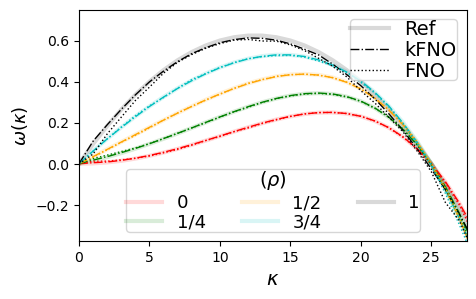

In [73]:
cmp_plt_dispersion_relation(  all_list_model_names, disp_rel_models, disp_rel_analytical, list_Lpi, list_rho , png_filename='drel_1d_beta25.png')


In [ ]:

def plt_operator_jacobian( all_list_model_names,  disp_rel_models,  disp_rel_analytical, list_Lpi, list_rho,png_filename):

    kk = np.arange(128+1);
    rho_colors=['r','g', 'orange', 'c' ,'k']
    model_style=['--','-.',':']
    model_name=['pFNO*','pFNO','pCNN40']

    fig, axs = plt.subplots(2,2, figsize=(8,8))

    Lpi_s=[0, 2]
    m_s  =[0, 2]
    
    for i, i_Lpi in enumerate(Lpi_s):
        for j, j_m in enumerate(m_s):
            # [idx_model,idx_Lpi,idx_rho,  :  ,  :]
            #(       3  ,   3   ,   5   , 129 , 129)
            ax = axs[i,j]   
            ax.imshow( jacobian_all[i_Lpi, j_m, -1,:50,:50 ] ) 
            
            ax.set_xlabel(r'$\kappa$', fontsize=14)
            ax.set_ylabel(r'$\kappa^*$', fontsize=14)

            ax.set_title(r'$J(\kappa,\kappa^*)$ of {}'.format(model_name[j_m]), fontsize=14)
     
    for ax in axs.flat:
        ax.label_outer()
        
    fig.tight_layout()
    plt.subplots_adjust(left=0.045, right=0.99, top=0.99, wspace=0.05)
        
        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)

#plt_operator_jacobian(  all_list_model_names, disp_rel_models, disp_rel_analytical, list_Lpi, list_rho , png_filename= None)
